# ***🔶Neural Networks - Mobile Price Prediction🔶***
***Mar 2026***

# 🔶Import Libraries

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew
from math import pi
import time

import missingno as msno

import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib import colormaps
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import  FunctionTransformer, PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, label_binarize
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDClassifier, LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import precision_score, recall_score, precision_recall_curve, roc_curve, auc, average_precision_score, PrecisionRecallDisplay, f1_score, accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

import joblib

# 🔶Data Overview

**Project Objective:**

The objective of this project is to develop and evaluate machine learning models for predicting the price range of mobile phones based on their technical specifications and hardware features. Using a structured dataset containing attributes such as battery capacity, processor performance, memory, camera resolution, and connectivity options.

The study applies both Logistic Regression and Neural Network approaches to perform multi-class classification. The workflow includes EDA, preprocessing, feature analysis, model training, and performance evaluation to identify the most effective predictive strategy.

**Dataset:**

| Feature           | Description                                                                                                               |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------- |
| **battery_power** | Battery capacity of the phone in milliampere-hours (mAh).                                                                 |
| **blue**          | Indicates whether the phone has Bluetooth (1 = Yes, 0 = No).                                                              |
| **clock_speed**   | Processor speed in gigahertz (GHz).                                                                                       |
| **dual_sim**      | Indicates whether the phone supports dual SIM cards (1 = Yes, 0 = No).                                                    |
| **fc**            | Front camera resolution in megapixels.                                                                                    |
| **four_g**        | Indicates whether the phone supports 4G technology (1 = Yes, 0 = No).                                                     |
| **int_memory**    | Internal storage memory in gigabytes (GB).                                                                                |
| **m_dep**         | Mobile depth (thickness) in centimeters.                                                                                  |
| **mobile_wt**     | Weight of the phone in grams.                                                                                             |
| **n_cores**       | Number of processor cores.                                                                                                |
| **pc**            | Primary (rear) camera resolution in megapixels.                                                                           |
| **px_height**     | Display resolution height in pixels.                                                                                      |
| **px_width**      | Display resolution width in pixels.                                                                                       |
| **ram**           | RAM size in megabytes (MB).                                                                                               |
| **sc_h**          | Screen height in centimeters.                                                                                             |
| **sc_w**          | Screen width in centimeters.                                                                                              |
| **talk_time**     | Battery talk time duration on a single charge.                                                                            |
| **three_g**       | Indicates whether the phone supports 3G technology (1 = Yes, 0 = No).                                                     |
| **touch_screen**  | Indicates whether the phone has a touchscreen (1 = Yes, 0 = No).                                                          |
| **wifi**          | Indicates whether the phone supports WiFi (1 = Yes, 0 = No).                                                              |
| **price_range**   | Target variable indicating the price category of the phone (0 to 3, where each number represents a different price tier). |


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/train_mobile_price.csv')
print('Shape of Dataset:', df.shape)
df.head()

Shape of Dataset: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
info = pd.DataFrame({'Name': df.columns,
                     'Missing Values':df.isnull().sum().values,
                     'Unique Values': df.nunique().values,
                     'Data Type': df.dtypes.values})

# Create a color map for styling
cm = sns.light_palette('orange', n_colors=20, as_cmap=True)

# Apply background gradient to the 'info' DataFrame
styled_info = info.style.background_gradient(cmap=cm)

styled_info

,Name,Missing Values,Unique Values,Data Type
0,battery_power,0,1094,int64
1,blue,0,2,int64
2,clock_speed,0,26,float64
3,dual_sim,0,2,int64
4,fc,0,20,int64
5,four_g,0,2,int64
6,int_memory,0,63,int64
7,m_dep,0,10,float64
8,mobile_wt,0,121,int64
9,n_cores,0,8,int64


**Initial Observations:**

Based on the preliminary inspection:
* The dataset contains 2000 samples and 21 features.
* No missing values are present.
* Column naming is clear and consistent.
* Data types appear appropriate for the variables.

Overall, the dataset is well-structured and ready for exploratory data analysis and preprocessing.

# 🔶Feature Engineering

In [ ]:
# Create total pixel count(indicating the overal resolution rather than individual dimensions)
df['px_total'] = df['px_height'] * df['px_width']

# Create screen area(captures physical display size better than two independent variables)
df['screen_area'] = df['sc_h'] * df['sc_w']


To better capture display quality and physical screen properties, two interaction-based features were created. The px_total feature represents the total number of pixels (px_height × px_width), providing a more meaningful indicator of overall screen resolution than treating height and width separately. Similarly, screen_area was derived from sc_h × sc_w to approximate the physical display size. Since these new features encode the combined information of their original components, the original columns (px_height, px_width, sc_h, sc_w) may be removed later to reduce redundancy.

In [ ]:
# Move target column to the end
target = 'price_range'
df = df[[col for col in df.columns if col != target] + [target]]
df.head(3)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,px_total,screen_area,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,2549,9,7,19,0,0,1,15120,63,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,2631,17,3,7,1,1,0,1799140,51,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,2603,11,2,9,1,1,0,2167308,22,2


# 🔶Train-Validation-Test Split

In [ ]:
# Train - test split
Train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['price_range'], random_state=42)
print(f'shape of initial train set: {Train_df.shape}')
print(f'shape of test set: {test_df.shape}')

shape of initial train set: (1600, 23)
shape of test set: (400, 23)


In [ ]:
# Train validation split
train_df, validation_df = train_test_split(Train_df, test_size=0.1, stratify=Train_df['price_range'], random_state=42)
print(f'shape of train set: {train_df.shape}')
print(f'shape of test set: {validation_df.shape}')

shape of train set: (1440, 23)
shape of test set: (160, 23)


# 🔶Exploratory Data Analysis (EDA)

## ⮞Univariate Analysis

In [ ]:
desc = train_df.describe()
styled_desc = desc.style.background_gradient(cmap=cm)
styled_desc

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,px_total,screen_area,price_range
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,1236.284028,0.497222,1.521528,0.504861,4.352778,0.517361,32.270139,0.507708,140.647222,4.565278,9.883333,651.440278,1248.236111,2121.335417,12.300000,5.809028,10.943750,0.762500,0.501389,0.518056,908676.108333,81.145139,1.500000
std,435.660518,0.500166,0.818723,0.500150,4.323666,0.499872,18.258889,0.291607,35.325556,2.296304,6.059836,445.677533,427.262633,1082.475955,4.193744,4.417924,5.470144,0.425699,0.500172,0.499847,826771.670944,78.451672,1.118422
min,502.000000,0.000000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,851.000000,0.000000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,4.000000,286.000000,881.000000,1210.750000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,268827.000000,20.000000,0.750000
50%,1225.000000,0.000000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,142.000000,5.000000,10.000000,573.500000,1247.000000,2130.000000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,616644.000000,54.000000,1.500000
75%,1604.000000,1.000000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,171.000000,7.000000,15.000000,960.250000,1613.000000,3049.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,1373836.500000,126.000000,2.250000
max,1997.000000,1.000000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3886306.000000,342.000000,3.000000


**Initial Observations**

Based on the descriptive statistics, some samples show zero values in features such as px_height and sc_w. Since these variables represent physical display dimensions, zero values may indicate unusual or potentially invalid entries. These cases will be further investigated during the EDA phase to determine whether they reflect real device specifications or require preprocessing adjustments.

In [ ]:
numeric_cols = ['battery_power','clock_speed', 'fc','int_memory', 'm_dep',
                'mobile_wt', 'n_cores', 'pc', 'px_height','px_width', 'ram',
                'sc_h', 'sc_w', 'talk_time','px_total', 'screen_area']

categorical_cols = ['blue', 'dual_sim','four_g','three_g','touch_screen', 'wifi', 'price_range']

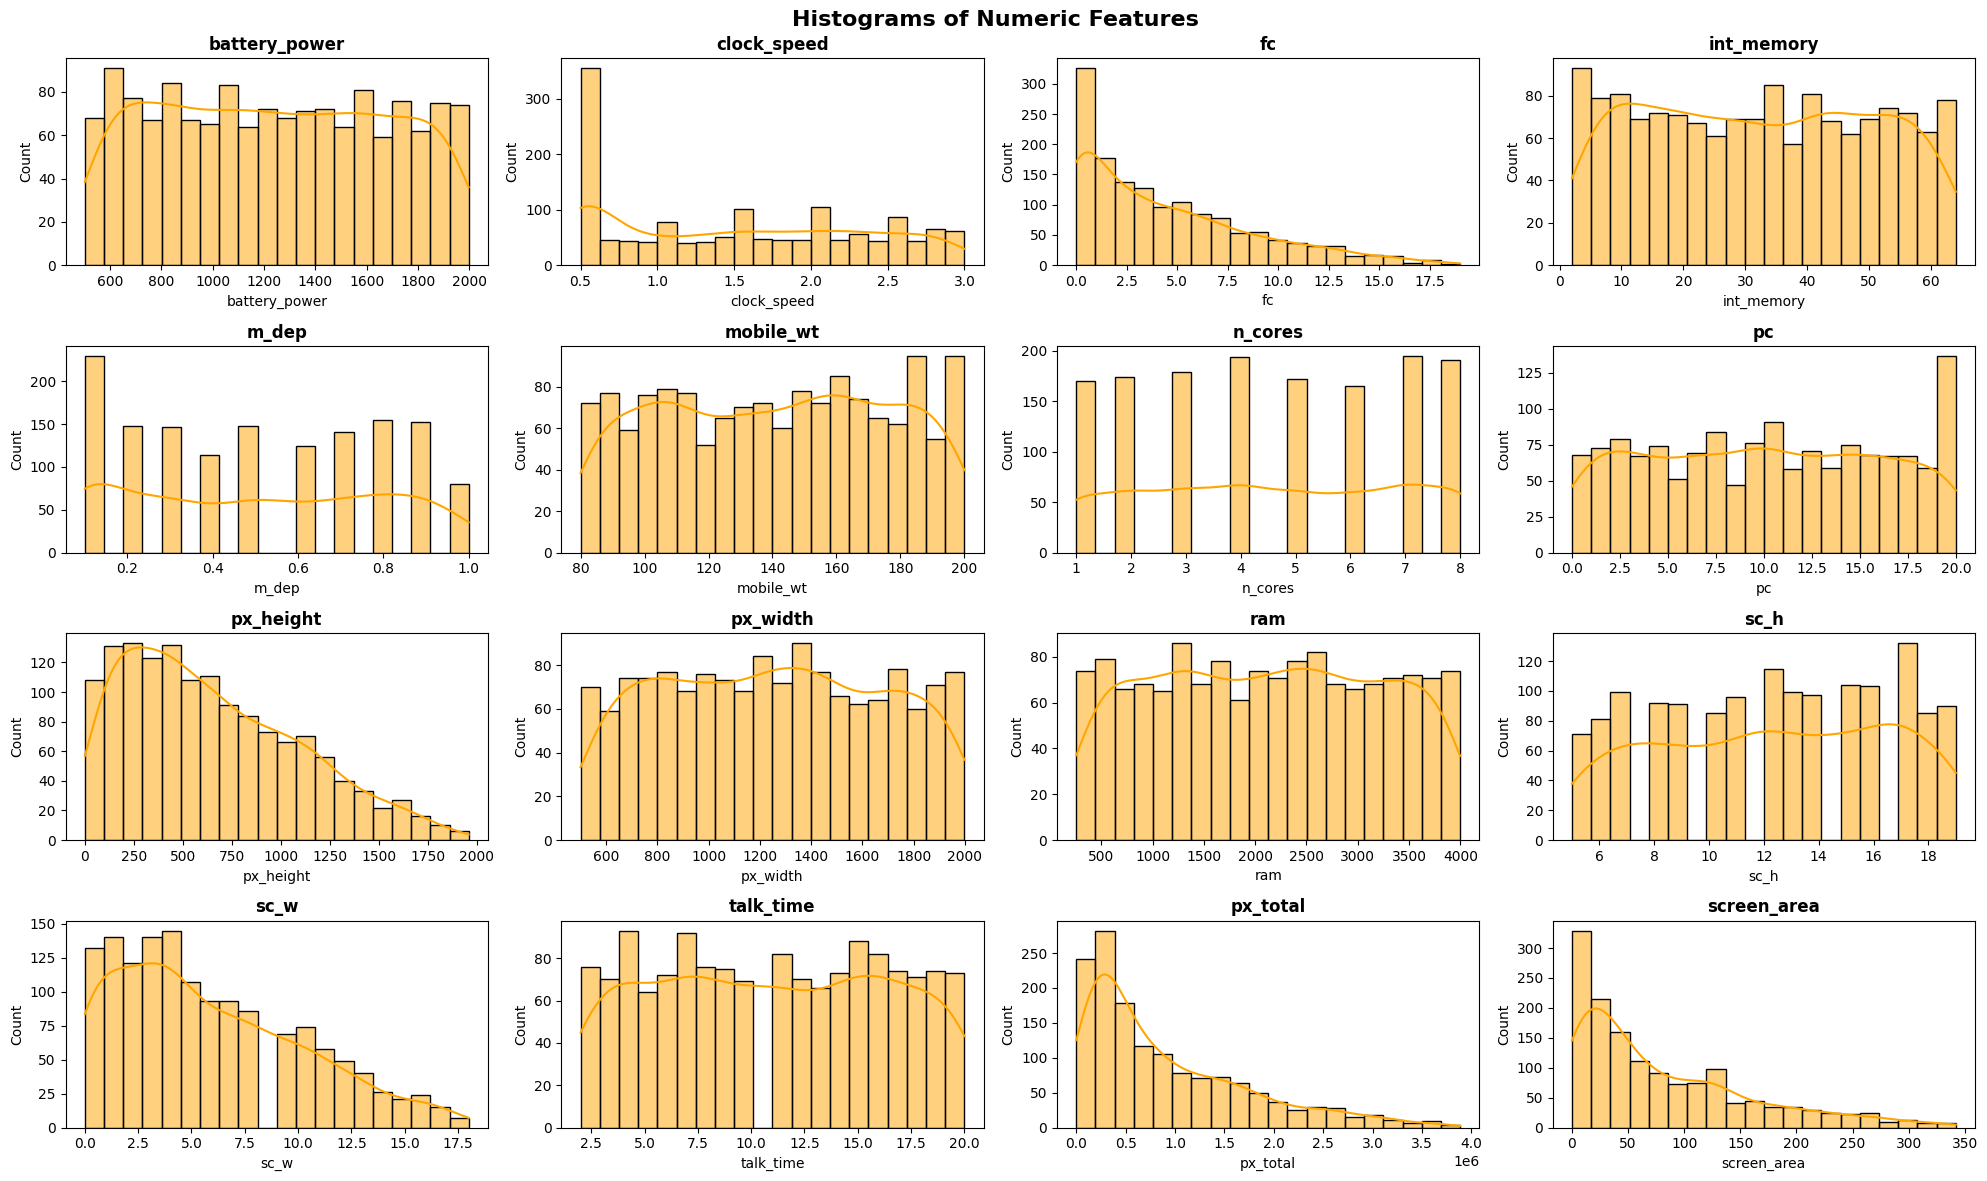

In [ ]:
# Histograms
fig, axes = plt.subplots(4,4, figsize=(20,12))
plt.suptitle('Histograms of Numeric Features',size=16, weight='bold')
flatten_ax = axes.flatten()

for i, col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  sns.histplot(train_df[col], bins=20, kde=True, color='orange', ax=ax)
  ax.set_title(col, weight='bold')

plt.tight_layout()
plt.show()

**Histogram Interpretation – Numeric Features**

* Several variables such as battery_power, int_memory, mobile_wt, px_width, and ram show approximately uniform distributions, suggesting balanced sampling across their ranges.

* The clock_speed feature exhibits a noticeable concentration at 0.5 GHz, creating a dominant bin compared to the rest of the distribution.

* Camera-related features show different behaviors: fc is strongly right-skewed with many zero values(representing no front camera), while pc is mostly uniform but contains a peak at its upper bound.

* Features like m_dep, n_cores, and sc_h have a limited number of discrete values, making them behave similarly to ordinal variables.

* Resolution and size-related variables (px_height, sc_w, px_total, and screen_area) display right-skewed distributions, indicating that higher-end display specifications are less frequent within the dataset.

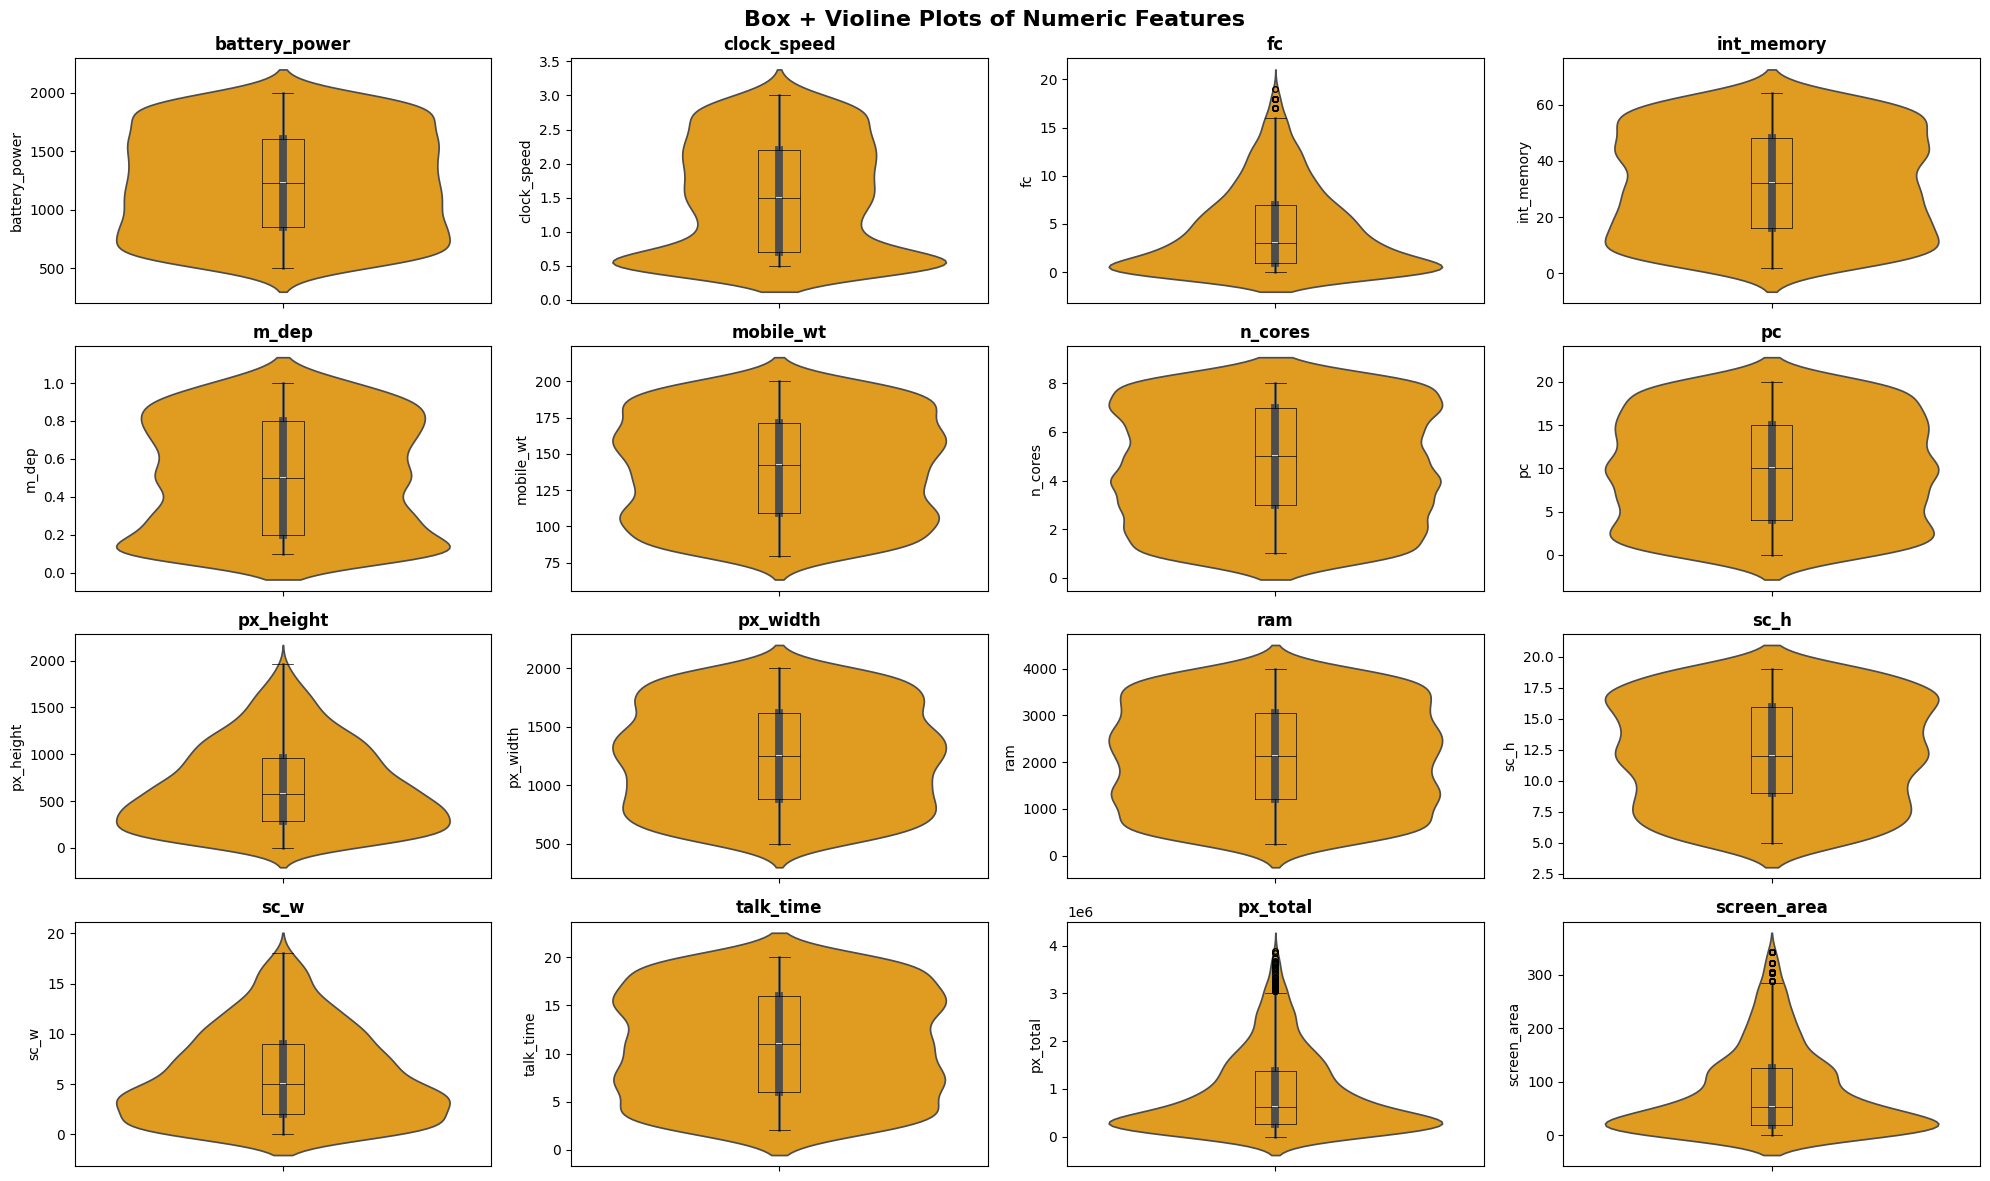

In [ ]:
# Box & Violin Plots
fig, axes = plt.subplots(4,4, figsize=(20,12))
plt.suptitle('Box + Violine Plots of Numeric Features',size=16, weight='bold')
flatten_ax = axes.flatten()

for i, col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  sns.violinplot(train_df[col], color='orange', ax=ax)
  sns.boxplot(train_df[col], color='k',fill=False, linewidth=0.5, width=0.1, fliersize=4, ax=ax)
  ax.set_title(col, weight='bold')

plt.tight_layout()
plt.show()

**Box & Violin Plot Interpretation:**

* The combined box and violin plots largely confirm the patterns observed in the histograms.
* They also highlight the presence of outliers in several features. Specifically, fc and screen_area have a few extreme values in the upper tail, while px_total shows a substantial number of high-value outliers.

These observations indicate that certain features may require preprocessing or outlier handling.

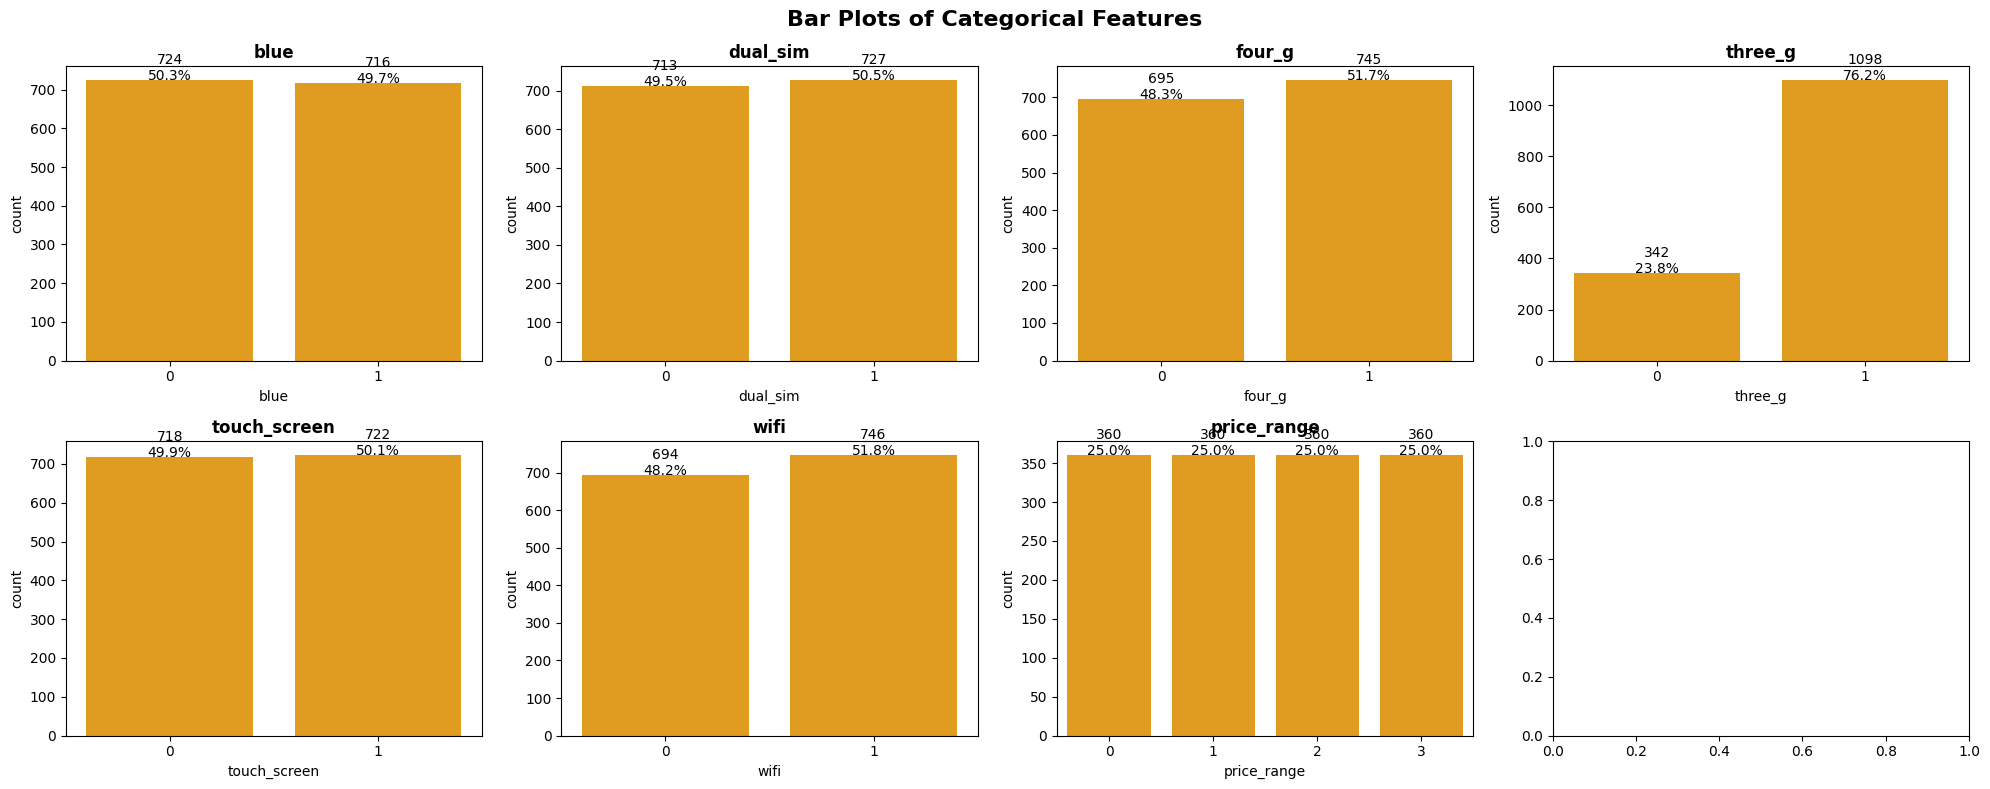

In [ ]:
# count plot of categorical features
fig, axes = plt.subplots(2,4, figsize=(20,8))
plt.suptitle('Bar Plots of Categorical Features', size=16, weight='bold')
flatten_ax = axes.flatten()

for i, col in enumerate(categorical_cols):
  ax = flatten_ax[i]
  sns.countplot(data=train_df, x=col, color='orange', ax=ax)
  ax.set_title(col, weight='bold')

  # annotate counts and percentages above bars
  for p in ax.patches:
    count = int(p.get_height())
    pct = count / len(train_df) *100
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.text(x, y, f'{count}\n{pct:.1f}%', ha='center')


plt.tight_layout()
plt.show()

**Categorical Feature Interpretation:**
* Most categorical variables appear well-balanced between their binary classes. Features such as blue, dual_sim, four_g, touch_screen, and wifi show nearly equal proportions, typically around a 50–50 split.
* The main exception is three_g, which is noticeably imbalanced, with approximately 76% of samples in class 1 and 24% in class 0.
* The target variable price_range is perfectly balanced across its four classes (25% each), which is beneficial for training unbiased classification models and simplifies evaluation.

## ⮞Bivariate Analysis

<Axes: >

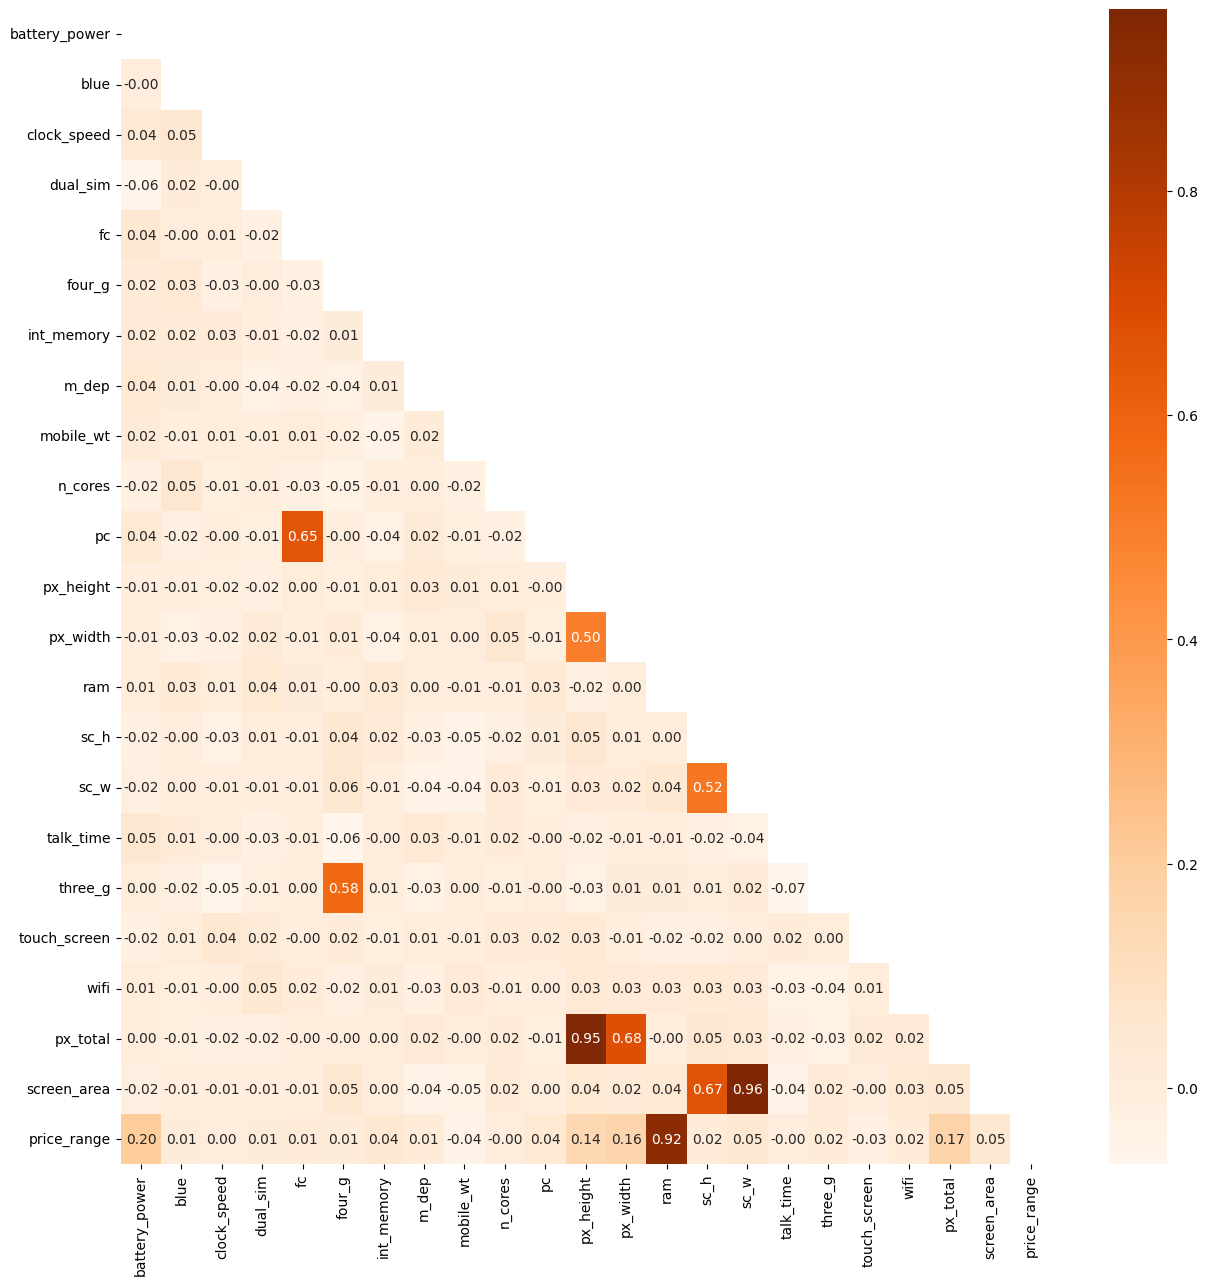

In [ ]:
# Heat map
plt.figure(figsize=(15,15))
corr = train_df.corr()
sns.heatmap(corr, fmt='.2f', cmap='Oranges', annot=True, mask=np.triu(corr))

**Correlation Analysis**
* Overall, most features show low pairwise correlations, indicating limited multicollinearity across the dataset.
* With respect to the target variable, ram has by far the strongest relationship (r ≈ 0.92), suggesting it is a dominant predictor of price range. It suggests that memory capacity is likely the dominant driver of price segmentation in this dataset.
* Moderate correlations are observed for battery_power (≈ 0.20), px_total (≈ 0.17), px_width (≈ 0.16), and px_height (≈ 0.14), while the remaining variables have relatively weak linear associations with the target.
* Among feature-to-feature relationships, expected correlations appear between related variables, such as pc and fc, three_g and four_g.
* Also, a strong correlation is observed between engineered features (px_total, screen_area) and their original components. Engineered interaction features introduce expected correlations with their source variables; therefore, model performance will later be evaluated with and without the original components to assess redundancy.
* Aside from these logical relationships, most feature pairs show minimal correlation.

In [ ]:
target_corr = corr[['price_range']].abs().sort_values(by='price_range', ascending=False)
target_corr

,price_range
price_range,1.000000
ram,0.917711
battery_power,0.202295
px_total,0.172409
px_width,0.160665
px_height,0.144514
screen_area,0.047857
sc_w,0.046482
int_memory,0.042384
mobile_wt,0.041211


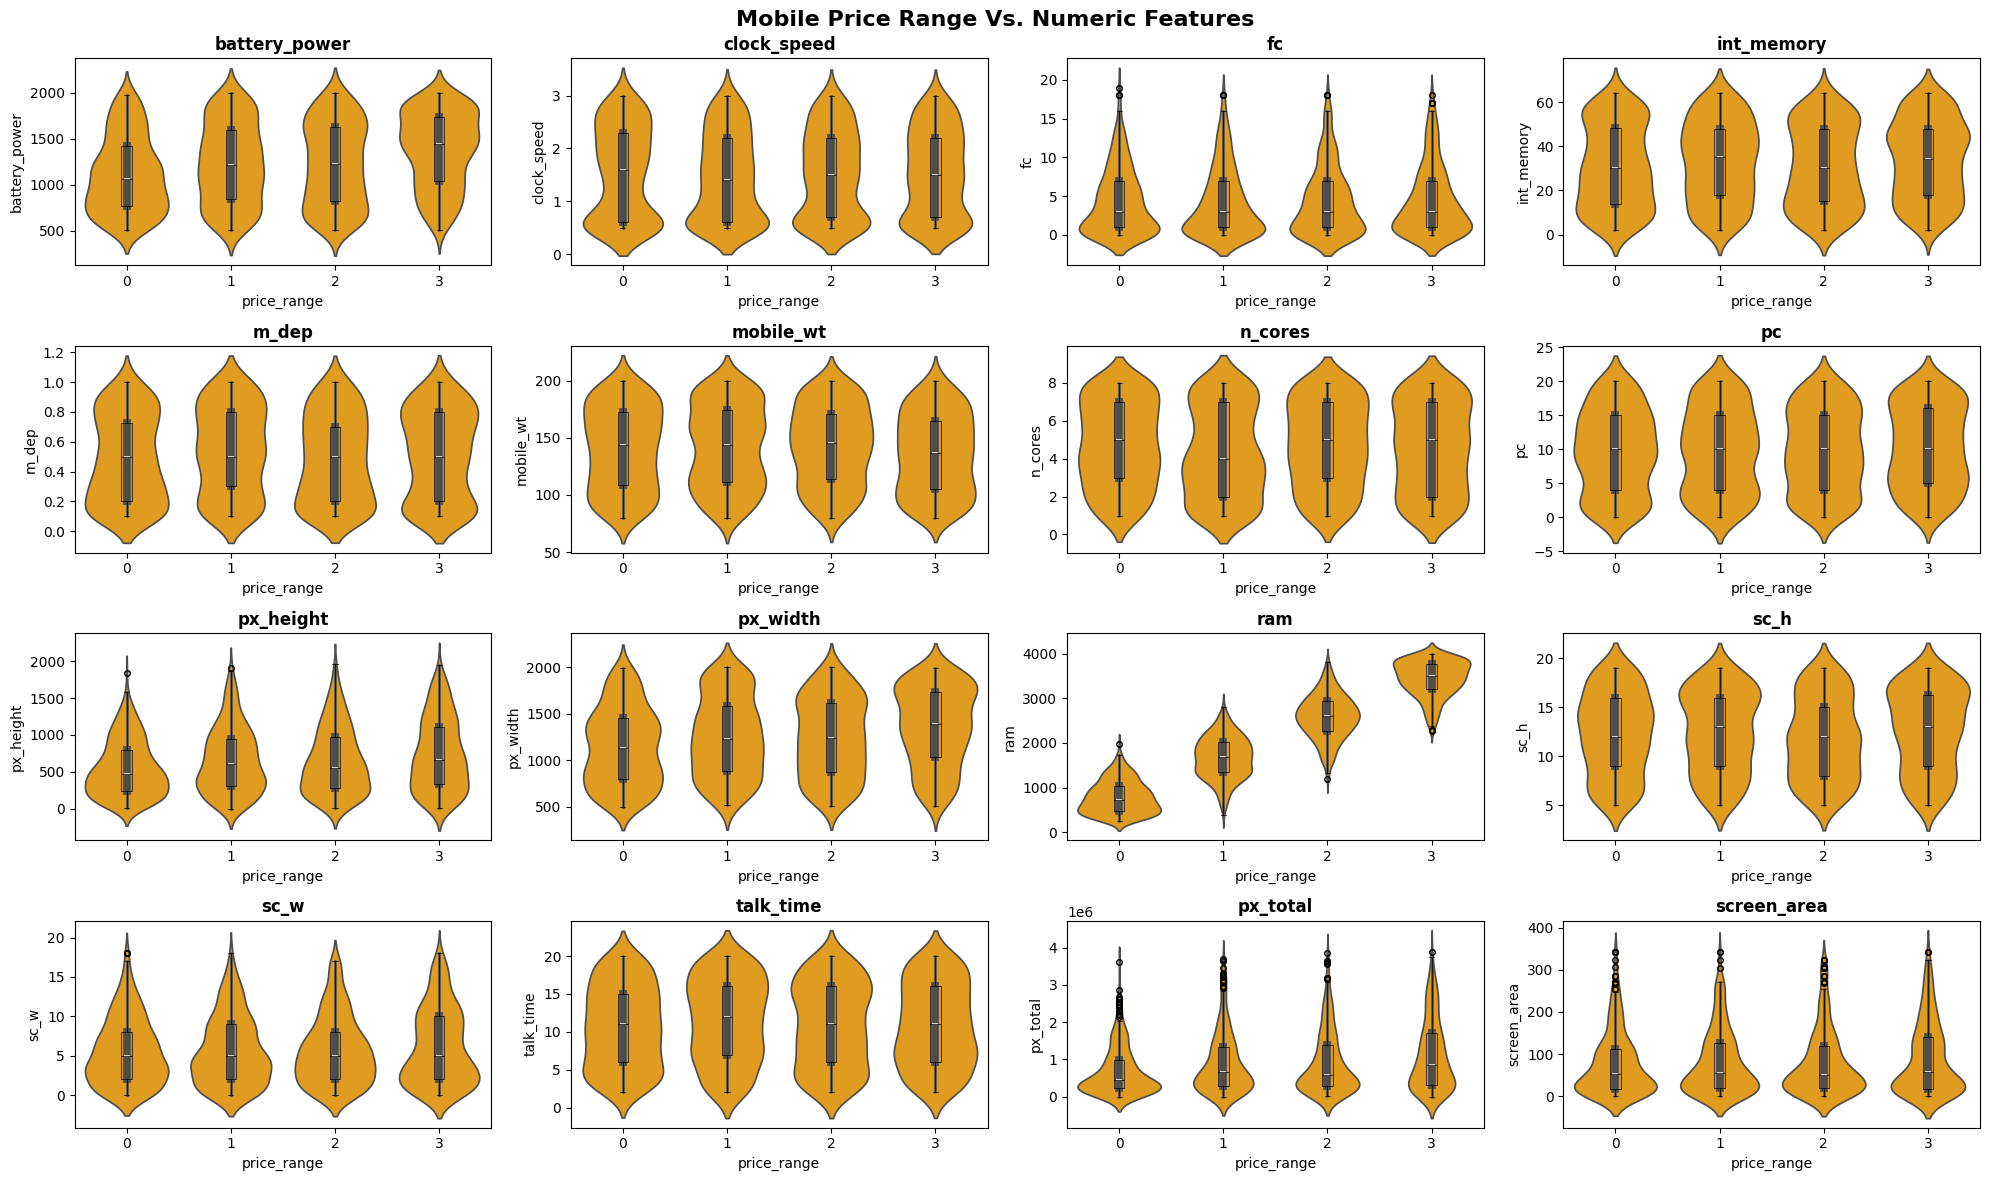

In [ ]:
# Target variable Vs. numeric features
fig, axes = plt.subplots(4,4, figsize=(20,12))
plt.suptitle(f'Mobile Price Range Vs. Numeric Features', weight='bold', size=16)
flatten_ax = axes.flatten()

for i, col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  sns.violinplot(data=train_df, x='price_range', y=col, ax=ax, color='orange')
  sns.boxplot(data=train_df, x='price_range', y=col, ax=ax, color='k', fill=False, linewidth=0.5, width=0.1, fliersize=4)
  ax.set_title(col, weight='bold')

plt.tight_layout()
plt.show()

**Numeric Features vs Target:**

* The violin plots reveal that most numeric variables have similar distributions across price classes, indicating weak discriminatory power. Features such as clock_speed, fc, int_memory, m_dep, mobile_wt, n_cores, pc, sc_h, sc_w, and talk_time show substantial overlap between classes, suggesting limited direct influence on price segmentation.

    The heavy overlap across many predictors suggests that non-linear complexity may provide limited additional gain beyond strong linear signals already present in the data.

* In contrast, ram exhibits a very clear monotonic relationship with price_range, where higher RAM values correspond to higher price tiers, confirming the strong correlation observed earlier. It means the classification boundary may be largely driven by a single dominant feature, meaning simpler models could already achieve strong performance.

* battery_power and resolution-related features (px_width, px_total) show mild trends, with higher-value distributions appearing more frequently in higher price classes, although the separation is less pronounced.

* Engineered features (px_total, screen_area) retain right-skewed distributions with upper-tail outliers, reflecting the presence of a smaller number of high-spec devices. Overall, the visualizations suggest that only a few features contribute strongly to class separation, while many others provide complementary but weaker signals.

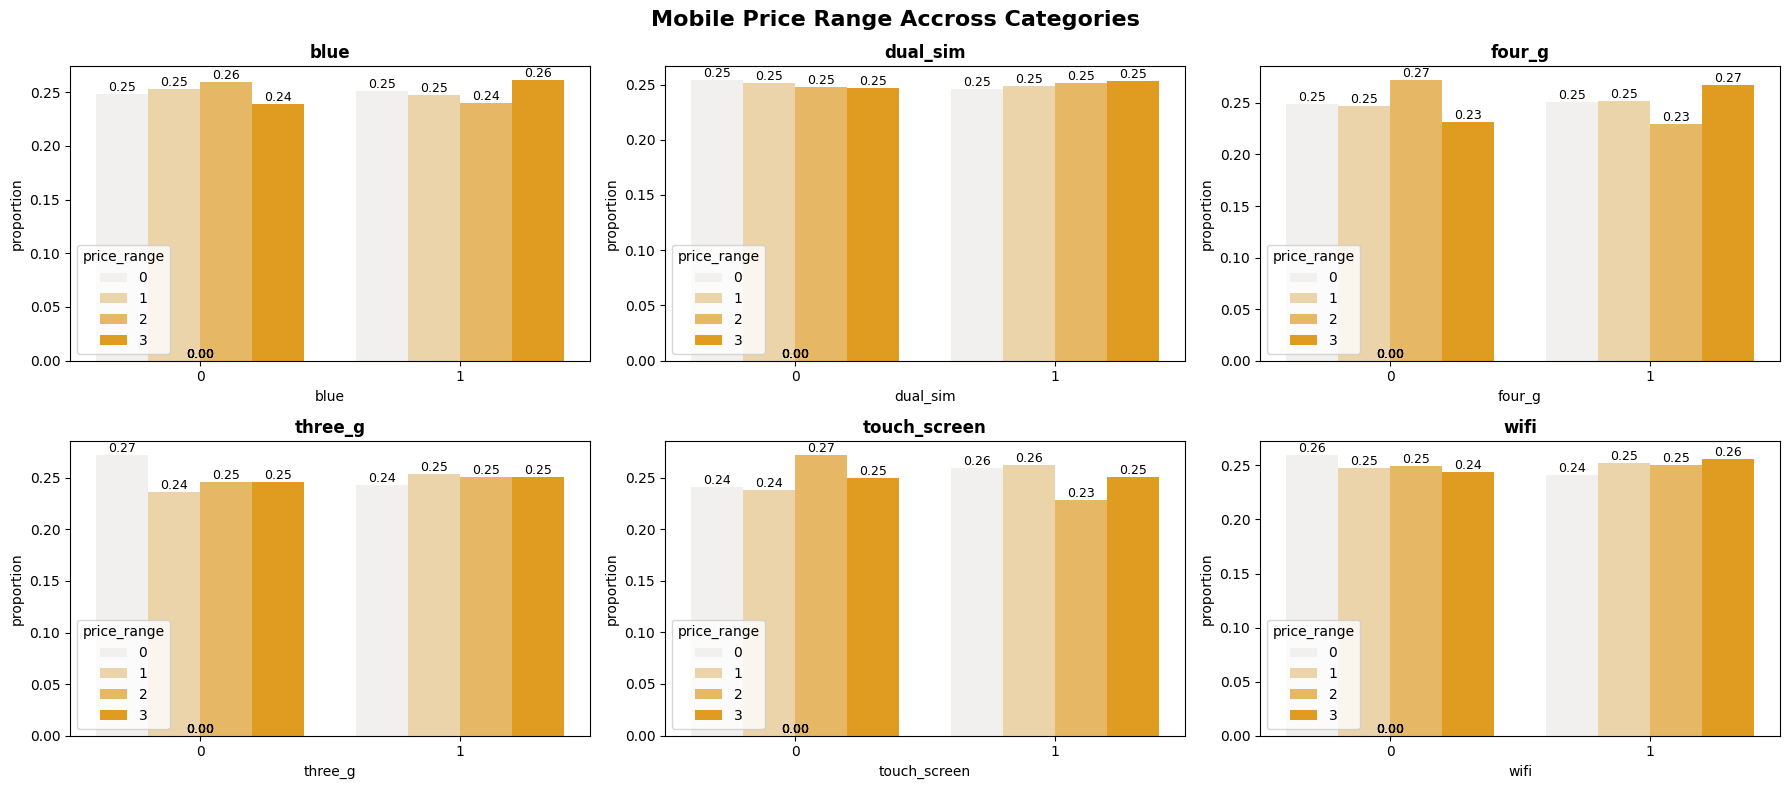

In [ ]:
# Target variable Vs Categorical features

binary_cols = ['blue', 'dual_sim','four_g','three_g','touch_screen', 'wifi']
fig, axes = plt.subplots(2,3, figsize=(18,8))
plt.suptitle('Mobile Price Range Accross Categories', weight='bold', size=16)
flatten_ax = axes.flatten()

for i,col in enumerate(binary_cols):
  ax = flatten_ax[i]

  # Compute proportions within each category
  prop_df = (train_df.groupby([col, 'price_range'], as_index=False).size())
  prop_df['proportion'] = (prop_df.groupby(col)['size'].transform(lambda x: x / x.sum())) # For each category value: proportion=count in group/total count for that category

  # Plot
  sns.barplot(data=prop_df, x=col, y='proportion', hue='price_range',palette='light:orange', ax=ax)
  ax.set_title(col, weight='bold')

  # Annotate bars
  for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
            )

plt.tight_layout()
plt.show()

**Binary Features Vs Target:**

The proportional bar plots indicate that the target variable (price_range) is nearly uniformly distributed across all binary categories (blue, dual_sim, four_g, three_g, touch_screen, wifi). Each class contributes roughly 23–27% within both category levels, suggesting that these features have limited standalone discriminatory power. The absence of strong proportional shifts implies that these variables may act as weak predictors individually, though they could still contribute marginally through interactions within multivariate models.


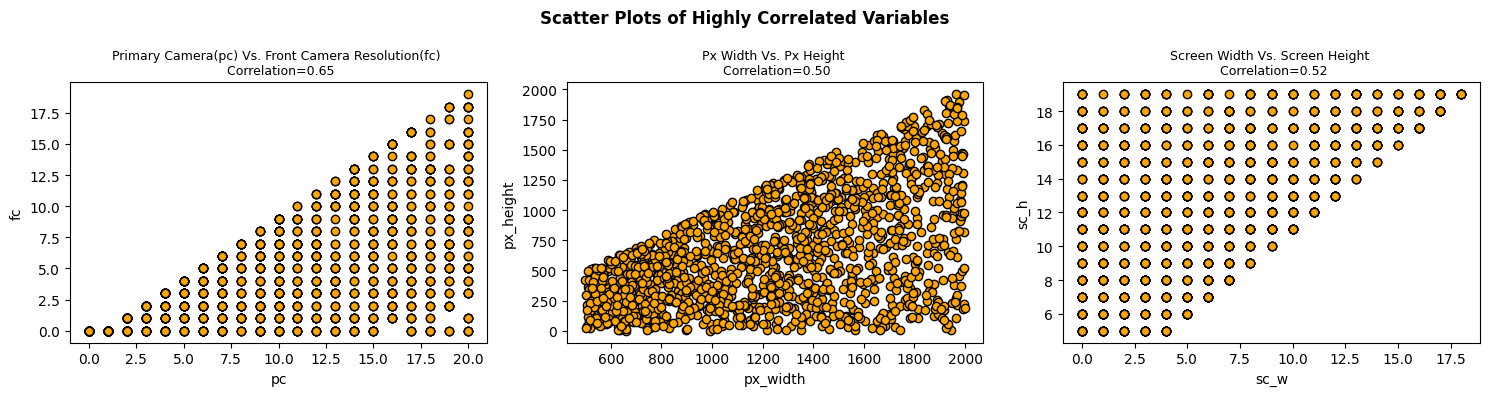

In [ ]:
# Scatter plots of highly correlated features

fig,ax = plt.subplots(1,3, figsize=(15,4))
plt.suptitle('Scatter Plots of Highly Correlated Variables', weight='bold')

ax[0].scatter(x=train_df['pc'], y=train_df['fc'], color='orange',ec='k')
ax[0].set_title(f'Primary Camera(pc) Vs. Front Camera Resolution(fc) \n Correlation={corr['pc']['fc']:.2f}', size=9)
ax[0].set_xlabel('pc')
ax[0].set_ylabel('fc')

ax[1].scatter(x=train_df['px_width'], y=train_df['px_height'], color='orange',ec='k')
ax[1].set_title(f'Px Width Vs. Px Height \n Correlation={corr['px_height']['px_width']:.2f}', size=9)
ax[1].set_xlabel('px_width')
ax[1].set_ylabel('px_height')

ax[2].scatter(x=train_df['sc_w'], y=train_df['sc_h'], color='orange',ec='k')
ax[2].set_title(f'Screen Width Vs. Screen Height \n Correlation={corr['sc_w']['sc_h']:.2f}', size=9)
ax[2].set_xlabel('sc_w')
ax[2].set_ylabel('sc_h')

plt.tight_layout()
plt.show()

**Interpretation of Highly Correlated Feature Pairs:**
* Primary Camera (pc) vs Front Camera (fc) — corr ≈ 0.65:
The scatter plot forms a bounded triangular region where fc does not exceed pc, indicating a structural constraint between the two variables. This reflects realistic device design patterns in which the front camera resolution scales with — but typically remains lower than — the primary camera resolution.

* Pixel Width vs Pixel Height — corr ≈ 0.50:
The observations occupy a wedge-shaped region rather than a symmetric cloud, suggesting proportional scaling between image dimensions.

* Screen Width (sc_w) vs Screen Height (sc_h) — corr ≈ 0.52:
The lattice-like structure and clear oblique boundary imply integer-based engineering specifications. Devices appear constrained within a feasible design region where screen height increases with screen width, producing a structured, non-linear relationship rather than a purely linear trend.

**Note on Zero and Small Integer Values:**
* The zero values observed earlier in the univariate analysis (e.g., px_height and sc_w) reappear here in structured geometric patterns rather than as isolated anomalies.
* Because these values align along consistent boundaries and discrete grid levels, they are unlikely to represent missing or erroneous entries.
* Instead, they likely correspond to valid low-end or baseline device configurations generated from predefined integer specifications.
* Therefore, no imputation or removal will be performed, as the data distribution suggests intentional design constraints rather than data quality issues.

## ⮞Multivariate Analysis

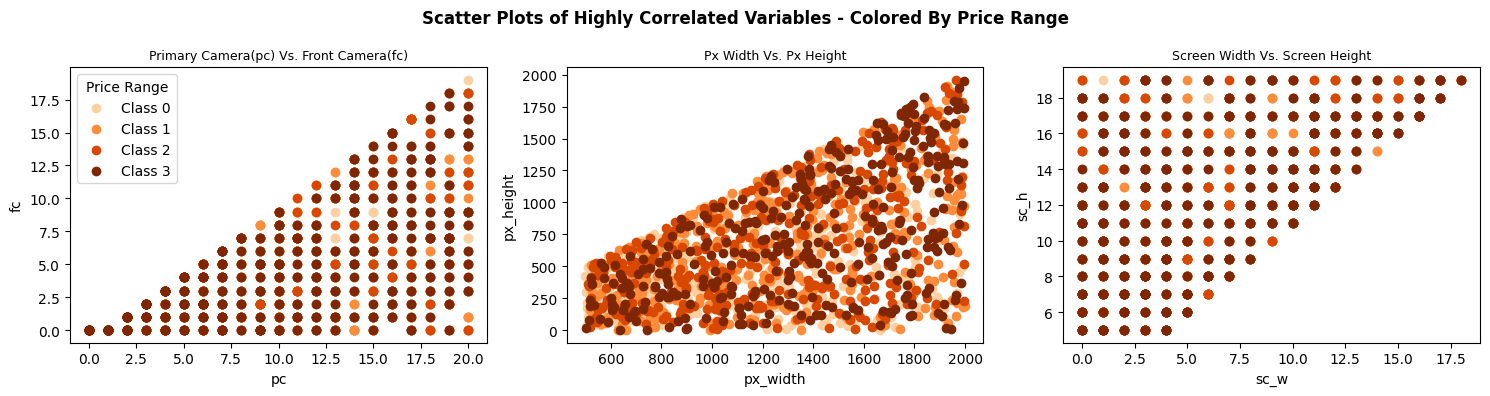

In [ ]:
# Scatter plots of highly correlated features - colored by price range

fig, ax = plt.subplots(1,3, figsize=(15,4))
plt.suptitle('Scatter Plots of Highly Correlated Variables - Colored By Price Range', weight='bold')

classes = sorted(train_df['price_range'].unique())
cmap = plt.cm.Oranges

for cls in classes:
    subset = train_df[train_df['price_range'] == cls]
    color = cmap((cls+1)/len(classes))   # spaced colors

    ax[0].scatter(subset['pc'], subset['fc'], color=color, label=f'Class {cls}')
    ax[1].scatter(subset['px_width'], subset['px_height'], color=color)
    ax[2].scatter(subset['sc_w'], subset['sc_h'], color=color)

ax[0].set_title('Primary Camera(pc) Vs. Front Camera(fc)', size=9)
ax[0].set_xlabel('pc')
ax[0].set_ylabel('fc')
ax[0].legend(title='Price Range')

ax[1].set_title('Px Width Vs. Px Height', size=9)
ax[1].set_xlabel('px_width')
ax[1].set_ylabel('px_height')

ax[2].set_title('Screen Width Vs. Screen Height', size=9)
ax[2].set_xlabel('sc_w')
ax[2].set_ylabel('sc_h')

plt.tight_layout()
plt.show()

**Interpretation — Class-colored scatter plots:**

* At first glance, class 3 appears visually dominant in the first and third plots. However, this is a visualization artifact rather than a true class imbalance. Because these features have discrete integer values, many observations overlap in the same coordinate locations. As confirmed earlier in the count analysis, the target variable is perfectly balanced, so this apparent dominance is caused by overplotting rather than unequal sample sizes.

* Across all three scatter plots, no clear class-wise separation or decision boundary is observable. The distributions of different price ranges largely overlap, indicating that these feature pairs (pc–fc, px_width–px_height, and sc_w–sc_h) do not independently discriminate between price categories. These variables show limited predictive structure when examined jointly, suggesting they may contribute only weakly to class separation unless combined with more informative features.

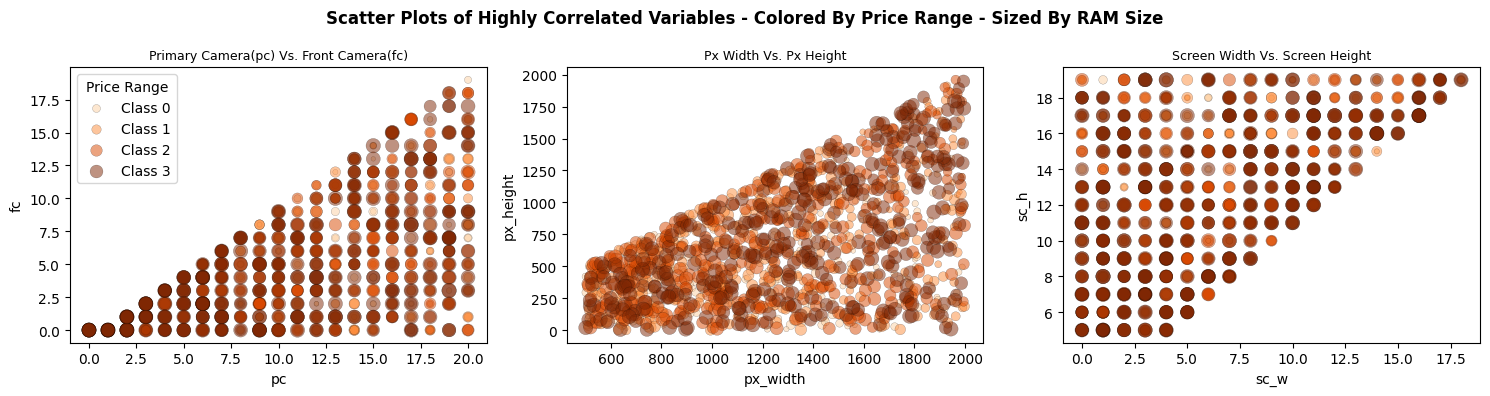

In [ ]:
# Scatter plots of highly correlated features - colored by price range - sized by ram

fig, ax = plt.subplots(1,3, figsize=(15,4))
plt.suptitle('Scatter Plots of Highly Correlated Variables - Colored By Price Range - Sized By RAM Size', weight='bold')

classes = sorted(train_df['price_range'].unique())
cmap = plt.cm.Oranges

# Normalize RAM for marker size
ram_scaled = (train_df['ram'] - train_df['ram'].min()) / (train_df['ram'].max() - train_df['ram'].min())
ram_size = 10 + ram_scaled * 100  # sizes between 10 and 100

for cls in classes:
    mask = train_df['price_range'] == cls
    subset = train_df[mask]
    size_subset = ram_size[mask]

    color = cmap((cls+1)/len(classes))

    ax[0].scatter(subset['pc'], subset['fc'],
                  color=color, s=size_subset,
                  alpha=0.5, edgecolors='k', linewidths=0.2,
                  label=f'Class {cls}')

    ax[1].scatter(subset['px_width'], subset['px_height'],
                  s=size_subset, alpha=0.5,
                  edgecolors='k', linewidths=0.2,
                  color=color)

    ax[2].scatter(subset['sc_w'], subset['sc_h'],
                  s=size_subset, alpha=0.5,
                  edgecolors='k', linewidths=0.2,
                  color=color)


ax[0].set_title('Primary Camera(pc) Vs. Front Camera(fc)', size=9)
ax[0].set_xlabel('pc')
ax[0].set_ylabel('fc')
ax[0].legend(title='Price Range')

ax[1].set_title('Px Width Vs. Px Height', size=9)
ax[1].set_xlabel('px_width')
ax[1].set_ylabel('px_height')

ax[2].set_title('Screen Width Vs. Screen Height', size=9)
ax[2].set_xlabel('sc_w')
ax[2].set_ylabel('sc_h')

plt.tight_layout()
plt.show()

**Interpretation — Multivariate Scatter Plots (Color = Price Range, Size = RAM)**

The bubble size encoding reinforces the dominant role of RAM in determining price range. Larger markers, representing higher RAM capacity, are mostly associated with darker shades (higher price categories), while smaller markers cluster within lighter colors (lower price tiers). This consistent gradient confirms the strong monotonic relationship previously observed in the correlation analysis.

Despite this RAM-driven separation, the spatial distribution of points across the three feature pairs remains highly overlapping, indicating that camera specifications and screen dimensions alone do not provide clear class boundaries. Instead, RAM appears to act as the primary discriminative signal, while the other variables contribute only marginal structural variation.

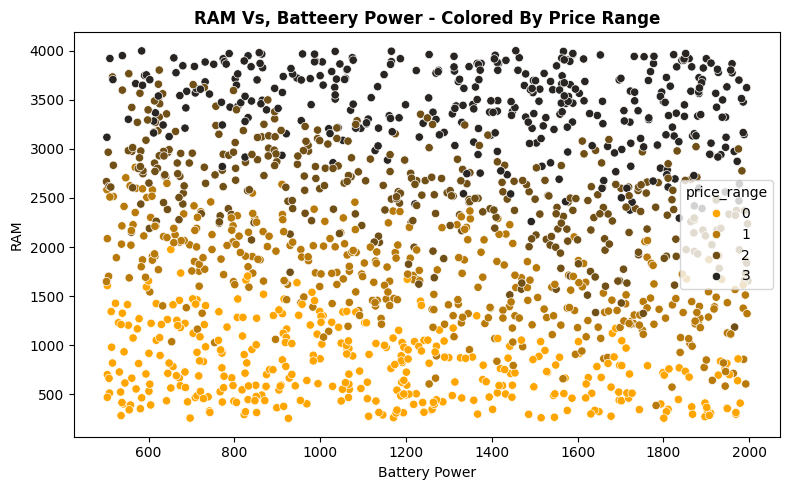

In [ ]:
plt.figure(figsize=(8,5))
plt.title(f'RAM Vs, Batteery Power - Colored By Price Range', weight='bold')
sns.scatterplot(x=train_df['battery_power'], y=train_df['ram'], hue=train_df['price_range'], palette='dark:orange_r')
plt.xlabel('Battery Power')
plt.ylabel('RAM')
plt.tight_layout()

Interpretation — RAM vs. Battery Power (Colored by Price Range)

This visualization further highlights the dominant influence of RAM on price categorization. Clear separation between classes is visible along the RAM axis, confirming the strong monotonic relationship identified in the correlation analysis. In contrast, battery power shows substantial overlap across all price tiers, indicating a comparatively weaker discriminative effect.

# 🔶Outliers

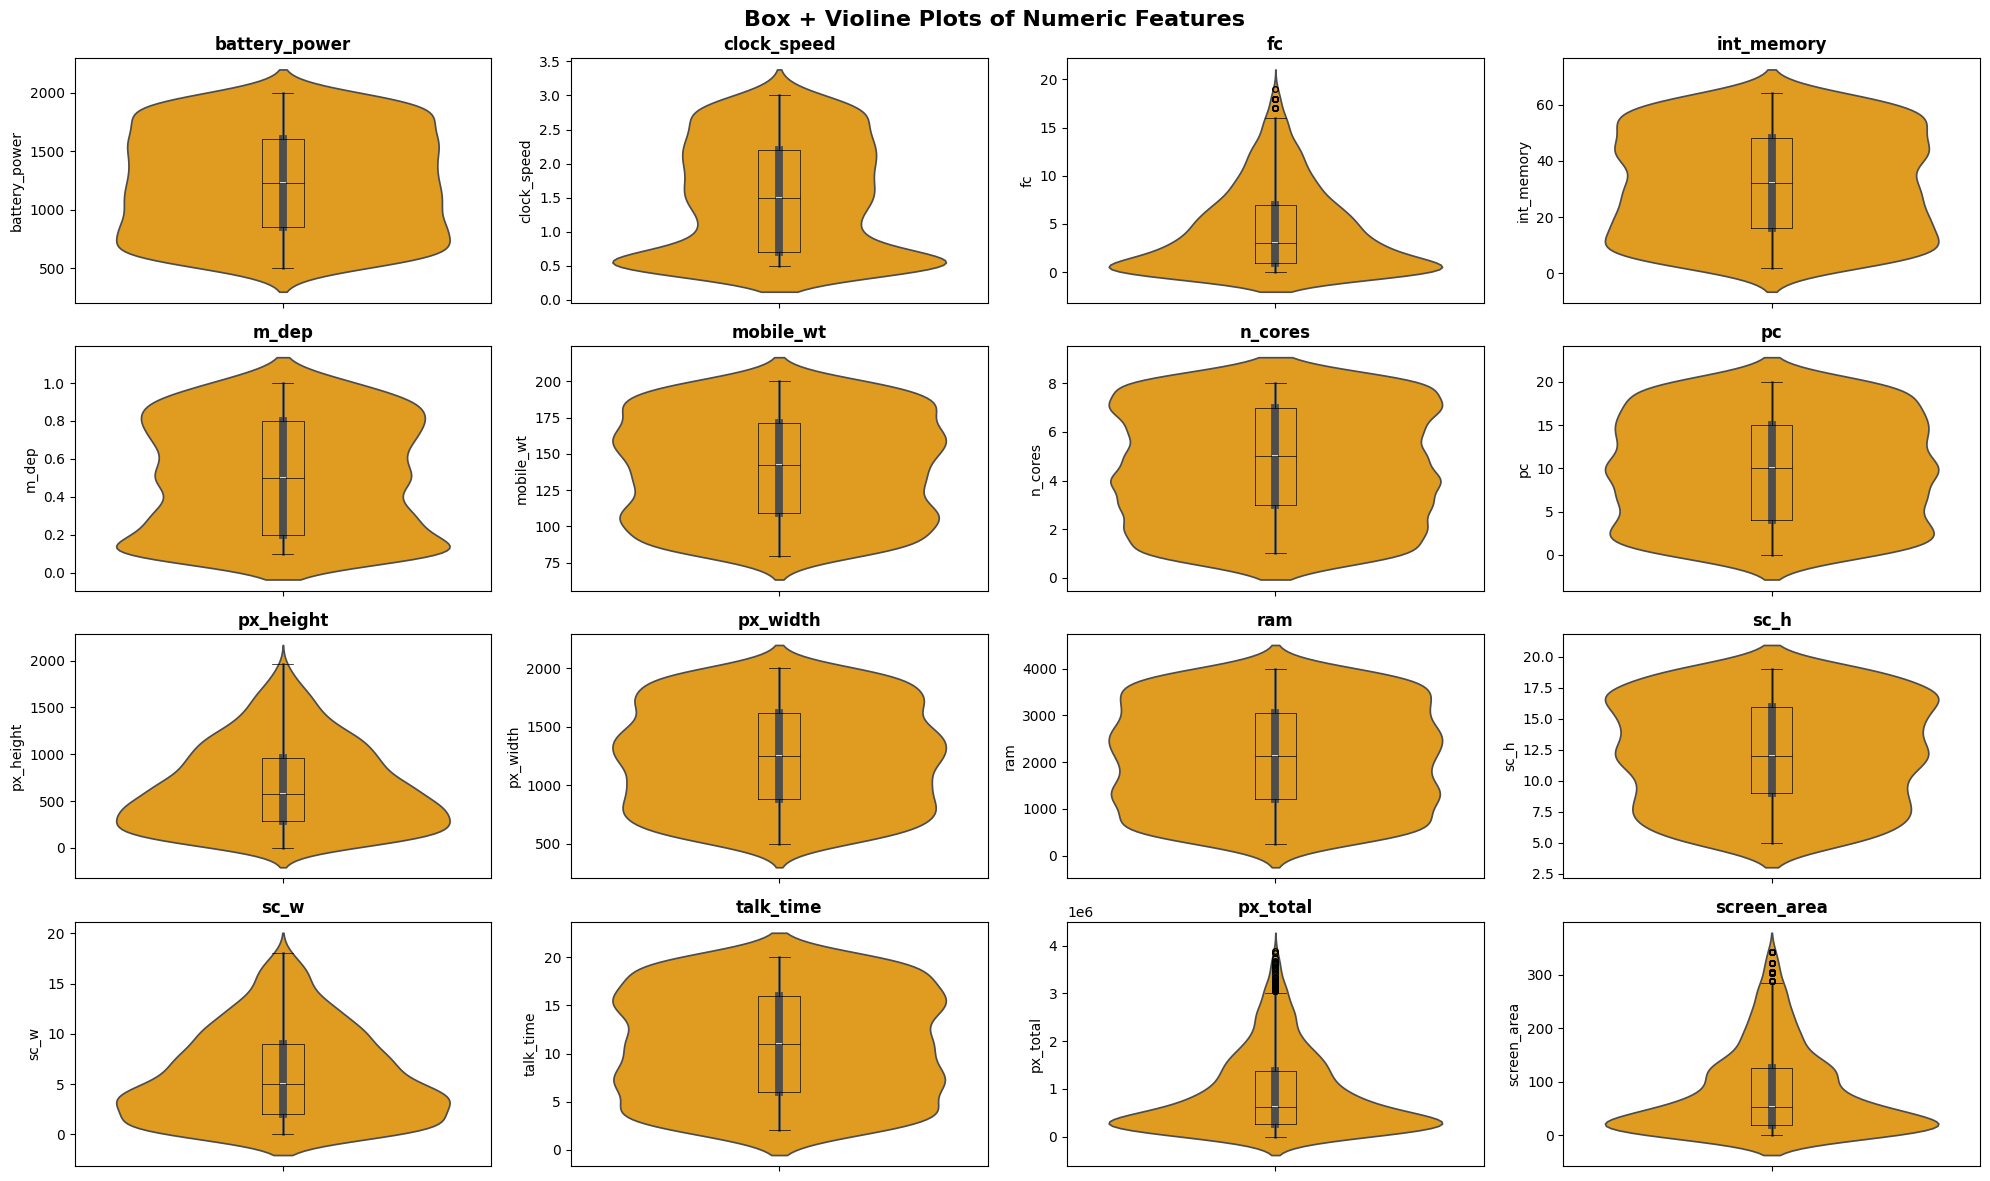

In [ ]:
# Box & Violin Plots
fig, axes = plt.subplots(4,4, figsize=(20,12))
plt.suptitle('Box + Violine Plots of Numeric Features',size=16, weight='bold')
flatten_ax = axes.flatten()

for i, col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  sns.violinplot(train_df[col], color='orange', ax=ax)
  sns.boxplot(train_df[col], color='k',fill=False, linewidth=0.5, width=0.1, fliersize=4, ax=ax)
  ax.set_title(col, weight='bold')

plt.tight_layout()
plt.show()

Several numeric features exhibit positive skewness and upper-tail concentration, as observed in the violin and box plots. Since Logistic Regression model will be used, highly skewed distributions can disproportionately influence coefficient estimation and destabilize the decision boundary.
Therefore, a Yeo–Johnson power transformation will be applied to reduce skewness and stabilize variance.

A separate untransformed dataset is retained for Neural Network experiments in order to evaluate the effect of distributional normalization on different model families.

In [ ]:
# Make a copy of train & validation sets to apply feature transformation
preprocessed_train_df = train_df.copy()
preprocessed_val_df = validation_df.copy()

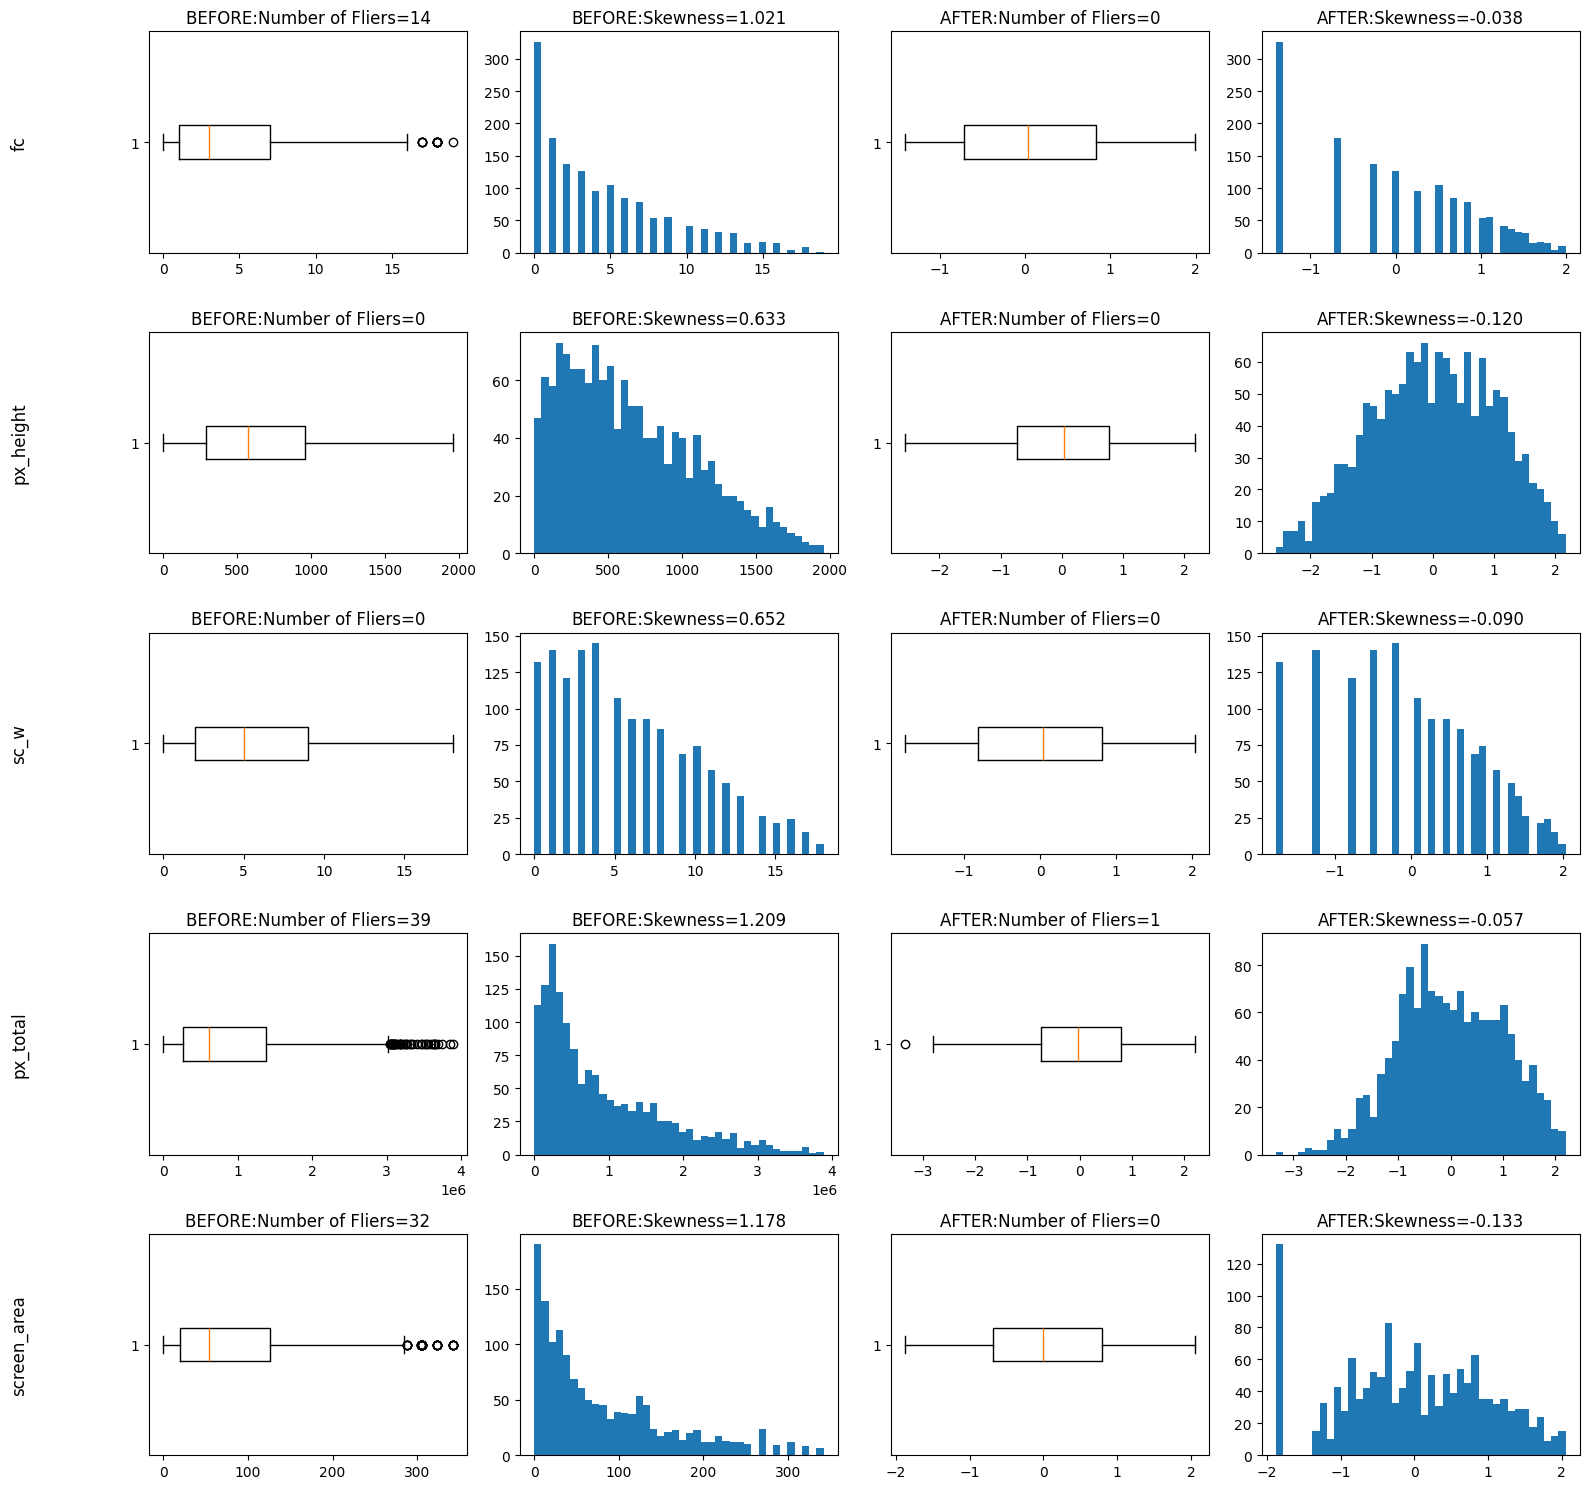

In [ ]:
# Feature Transform using Yeo-Johnson Transformer:
cols_to_transform = ['fc', 'px_height', 'sc_w', 'px_total', 'screen_area']

fig, ax = plt.subplots(len(cols_to_transform), 4, figsize=(16,3*len(cols_to_transform)))
for i, col in enumerate(cols_to_transform):
  ax[i, 0].set_ylabel(col, rotation=90, labelpad=80, fontsize=12, va='center')

  # box plot of the original feature
  fliers = ax[i,0].boxplot(preprocessed_train_df[col], vert=False, whis=1.5)['fliers'][0].get_ydata()
  ax[i,0].set_title(f'BEFORE:Number of Fliers={len(fliers)}')

  # Histogram of original feature
  skewness_orig = skew(preprocessed_train_df[col])
  ax[i,1].hist(preprocessed_train_df[col], 40)
  ax[i,1].set_title(f'BEFORE:Skewness={skewness_orig:.3f}')

  # box plot of yeo-johnson-transformed feature
  yeoj = PowerTransformer('yeo-johnson')
  transformed_feature = yeoj.fit_transform(preprocessed_train_df[[col]])
  yj_fliers = ax[i,2].boxplot(transformed_feature, vert=False, whis=1.5)['fliers'][0].get_ydata()
  ax[i,2].set_title(f'AFTER:Number of Fliers={len(yj_fliers)}')

  # Histogram of yeo-johnson-transformed feature
  skewness_yj = skew(transformed_feature)[0]
  ax[i,3].hist(transformed_feature, 40)
  ax[i,3].set_title(f'AFTER:Skewness={skewness_yj:.3f}')

plt.tight_layout()
plt.show()

**Interpretation of Results:**
* fc
  * Skewness reduced from 1.021 → -0.038
  * Number of fliers reduced from 14 → 0
  * Although skewness is effectively corrected, the feature remains discrete in nature, so the post-transformation histogram still reflects its ordinal structure rather than a perfectly continuous normal distribution.

* px_height
  * Skewness reduced from 0.633 → -0.120
  * No fliers before or after transformation
  * Distribution becomes approximately symmetric, indicating successful variance stabilization.

* sc_w
  * Skewness reduced from 0.652 → -0.090
  * No fliers in either case
  * Similar to fc, the feature is discrete, so while skewness is corrected, the distribution does not become fully Gaussian.

* px_total
  * Skewness reduced from 1.209 → -0.057
  * Fliers reduced from 39 → 1
  * The transformation substantially compresses the upper tail, improving symmetry and reducing extreme leverage points.

* screen_area
  * Skewness reduced from 1.178 → -0.133
  * Fliers reduced from 32 → 0
  * Distribution becomes approximately symmetric

In [ ]:
# Apply feature transformation on the train set
yeoj = PowerTransformer(method='yeo-johnson')
preprocessed_train_df[cols_to_transform] = yeoj.fit_transform(preprocessed_train_df[cols_to_transform])
print(f'Lambda={yeoj.lambdas_}')

# Apply feature transformation on the validation set
preprocessed_val_df[cols_to_transform] = yeoj.transform(preprocessed_val_df[cols_to_transform])

Lambda=[0.10249107 0.47239486 0.37362605 0.27583832 0.31711354]


It is worth mentioning that we already observed that "ram" dominates price prediction (the model’s decision boundary will still be largely driven by RAM) while other variables have weak marginal separation.
Moreover, skewness levels were moderate (~1.2 max), not extreme (>3 or 4).

That means transformation is likely to have only a marginal effect on Logistic Regression performance. It may slightly improve stability, but it probably will not dramatically affect the model's performance.

# 🔶Split X & Y

In [ ]:
# Original Train Set
# Separate the dataset into features (X) and the target variable (Y)
x_train = train_df.drop(columns=['price_range'])
y_train = train_df['price_range']

x_train.shape, y_train.shape

((1440, 22), (1440,))

In [ ]:
# Original Validation Set
# Separate the dataset into features (X) and the target variable (Y)
x_val = validation_df.drop(columns=['price_range'])
y_val = validation_df['price_range']

x_val.shape, y_val.shape

((160, 22), (160,))

In [ ]:
# Transformed Train Set
# Separate the dataset into features (X) and the target variable (Y)
x_train_transformed = preprocessed_train_df.drop(columns=['price_range'])
y_train_transformed = preprocessed_train_df['price_range']

x_train_transformed.shape, y_train_transformed.shape

((1440, 22), (1440,))

In [ ]:
# Transformed Validation Set
# Separate the dataset into features (X) and the target variable (Y)
x_val_transformed = preprocessed_val_df.drop(columns=['price_range'])
y_val_transformed = preprocessed_val_df['price_range']

x_val_transformed.shape, y_val_transformed.shape

((160, 22), (160,))

# 🔶Model Selection

**Modeling Strategy Overview:**

The goal of this project is to predict the mobile phone's price range using the mobile's technical specifications. This is a multi-class classification problem with a balanced target variable. For this problem, 3 models are trained and evaluated:

* Model 1: Logistic Regression implemented on original data
* Model 2: Logistic Regression implemented on transformed data
* Model 3: Neural Network


**Model Evaluation Insight:**

Accuracy is used as the primary scoring metric because the target classes are perfectly balanced, making accuracy a reliable and unbiased performance measure. In balanced multi-class settings, accuracy and F1-macro typically yield very similar conclusions. F1-macro is additionally monitored to confirm consistent performance across all classes.

## ⮞Model 1

In [ ]:
# Model1: Logistic regression - trained on original data
model1 = make_pipeline(StandardScaler(),
                       LogisticRegressionCV(class_weight='balanced',
                                             solver='saga',
                                             penalty='elasticnet',
                                             l1_ratios=np.linspace(0,1,10),
                                             cv=5,
                                             scoring='accuracy',
                                             random_state=10,
                                             max_iter=3000,
                                             n_jobs=-1)
                       )

In [ ]:
model1.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregressioncv',
                 LogisticRegressionCV(class_weight='balanced', cv=5,
                                      l1_ratios=array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
                                      max_iter=3000, n_jobs=-1,
                                      penalty='elasticnet', random_state=10,
                                      scoring='accuracy', solver='saga'))])

In [ ]:
# Optimal hyperparameters found through cross-validation
model1_logistic = model1.named_steps['logisticregressioncv']
print(f'Inverse regularization strength(C)={model1_logistic.C_}')
print(f'L1-ratio={model1_logistic.l1_ratio_}')

Inverse regularization strength(C)=[2.7825594 2.7825594 2.7825594 2.7825594]
L1-ratio=[1. 1. 1. 1.]


**Interpretation**

* Moderate regularization strength (C = 2.78):  
The parameter C controls the inverse of regularization strength. A moderate value indicates that the model benefits from some regularization but still retains sufficient flexibility to capture meaningful relationships in the data. Extremely small values (strong regularization) were not optimal, confirming that the features contain useful predictive signal.

* Pure L1 regularization selected (L1 ratio = 1.0):   
The cross-validation process selected pure L1 penalty over ElasticNet or L2. This is a significant result because L1 regularization performs automatic feature selection by shrinking less informative feature coefficients toward zero. This confirms that only a subset of features strongly contributes to price prediction, which aligns with earlier EDA findings showing RAM as the dominant predictor.

In [ ]:
y_pred_1 = model1.predict(x_val)
# Model Score
print(f'Model Score={accuracy_score(y_val, y_pred_1)}')
print(f'F1 macro={f1_score(y_val, y_pred_1, average='macro')}')

Model Score=0.975
F1 macro=0.9749942111762889


**Interpretation:**

* The model achieves very high predictive performance, correctly classifying 97.5% of validation samples.
* The F1-macro score is nearly identical to accuracy, confirming balanced performance across all classes.
* This validates that Logistic Regression is highly effective for this dataset despite being a linear model.

This strong performance is expected because earlier EDA showed clear separation between classes driven primarily by RAM.

In [ ]:
print(classification_report(y_val, y_pred_1))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        40
           1       0.95      1.00      0.98        40
           2       0.97      0.95      0.96        40
           3       0.97      0.97      0.97        40

    accuracy                           0.97       160
   macro avg       0.98      0.97      0.97       160
weighted avg       0.98      0.97      0.97       160



**Interpretation:**
* All classes achieve F1 scores between 0.96 and 0.99
* No class shows systematic weakness
* Performance is uniformly strong across the entire price spectrum

This confirms that the model generalizes well across all price ranges.

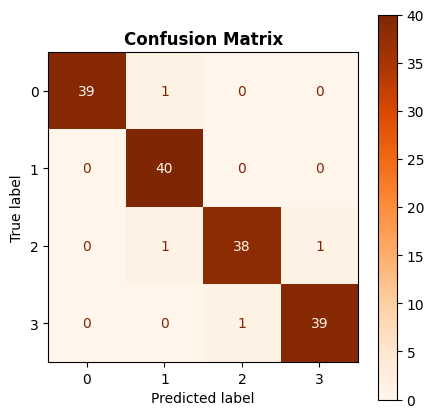

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_val, y_pred_1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Oranges", values_format="d")
ax.set_title("Confusion Matrix", weight="bold")
plt.show()

**Interpretation:**
* Only 4 misclassifications out of 160 samples
* Most errors occur between adjacent price ranges (e.g., class 2 and class 3). This is expected and logical because neighboring price ranges have similar specifications. This indicates the model correctly captures the ordinal structure of price ranges






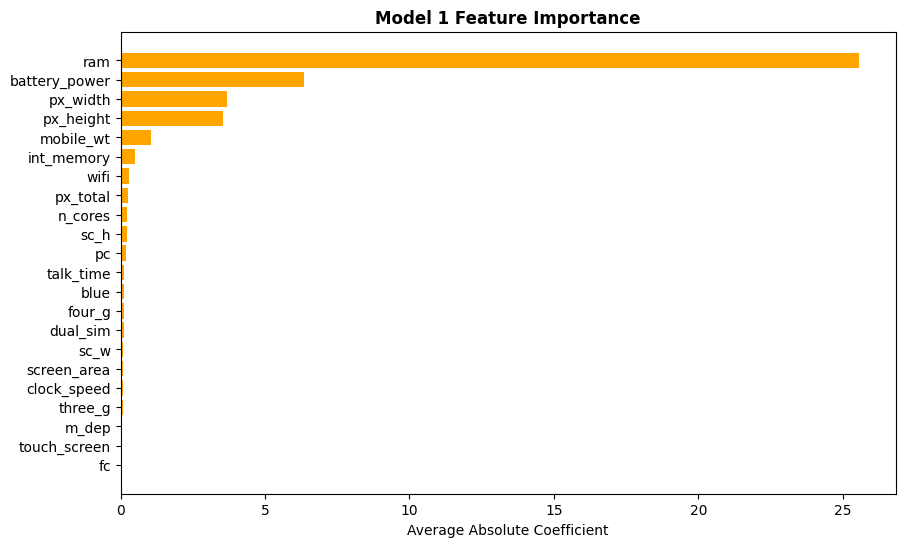

In [ ]:
# Get trained logistic regression model from pipeline
logreg = model1.named_steps['logisticregressioncv']

# Get feature names
feature_names = x_train.columns

# For multiclass, average absolute coefficient across classes
importance_lr = np.mean(np.abs(logreg.coef_), axis=0)

# Create DataFrame
importance_df_lr = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_lr
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df_lr['Feature'], importance_df_lr['Importance'], color='orange')
plt.gca().invert_yaxis()
plt.title('Model 1 Feature Importance', weight='bold')
plt.xlabel('Average Absolute Coefficient')
plt.show()

**Interpretation:**

RAM is the dominant feature, confirming previous correlation and visualization analysis. Its coefficient magnitude is substantially larger than other features, indicating that memory capacity is the primary determinant of mobile price range.

## ⮞Model 2

In [ ]:
# Model2: Logistic regression trained on transformed data
model2 = make_pipeline(StandardScaler(),
                       LogisticRegressionCV(class_weight='balanced',
                                             solver='saga',
                                             penalty='elasticnet',
                                             l1_ratios=np.linspace(0,1,10),
                                             cv=5,
                                             scoring='accuracy',
                                             random_state=10,
                                             max_iter=3000,
                                             n_jobs=-1)
                       )

In [ ]:
model2.fit(x_train_transformed,y_train_transformed)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregressioncv',
                 LogisticRegressionCV(class_weight='balanced', cv=5,
                                      l1_ratios=array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
                                      max_iter=3000, n_jobs=-1,
                                      penalty='elasticnet', random_state=10,
                                      scoring='accuracy', solver='saga'))])

In [ ]:
# Optimal hyperparameters found through cross-validation
model2_logistic = model2.named_steps['logisticregressioncv']
print(f'Inverse regularization strength(C)={model2_logistic.C_}')
print(f'L1-ratio={model2_logistic.l1_ratio_}')

Inverse regularization strength(C)=[21.5443469 21.5443469 21.5443469 21.5443469]
L1-ratio=[0.77777778 0.77777778 0.77777778 0.77777778]


**Interpretation:**

* Cross-validation selected an inverse regularization strength of C = 21.54: indicating a relatively low level of regularization compared to Model 1. The higher C value suggests that after transformation, the feature distributions became more suitable for linear separation, allowing the model to rely more on learned coefficients rather than strong regularization.

* The ElasticNet ratio below 1.0 indicates that a combination of L1 and L2 penalties provided the optimal balance between sparsity and coefficient stability.

In [ ]:
y_pred_2 = model2.predict(x_val_transformed)
# Model Score
print(f'Model Score={accuracy_score(y_val_transformed, y_pred_2)}')
print(f'F1 macro={f1_score(y_val_transformed, y_pred_2, average='macro')}')

Model Score=0.975
F1 macro=0.9749921826141339


**Interpretation:**

The transformed model achieved an accuracy of 97.5% and an F1-macro score of 0.975, which is essentially identical to the performance of the logistic regression trained on the original features. This confirms that the model maintains excellent predictive capability after feature transformation.

In [ ]:
print(classification_report(y_val_transformed, y_pred_2))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        40
           1       0.95      1.00      0.98        40
           2       0.97      0.97      0.97        40
           3       0.97      0.97      0.97        40

    accuracy                           0.97       160
   macro avg       0.98      0.97      0.97       160
weighted avg       0.98      0.97      0.97       160



**Interpretation:**

The classification report shows consistently high precision and recall across all four classes, indicating that the model performs uniformly well without bias toward any specific price range. The balanced performance across classes confirms that the decision boundaries remain well defined after transformation.

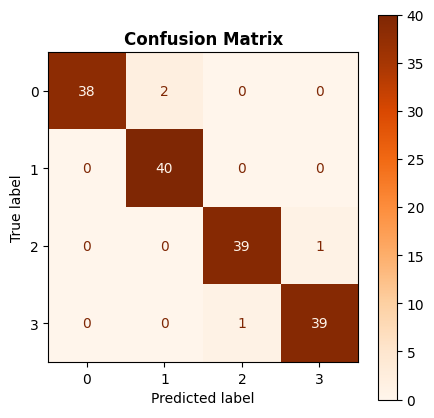

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_val_transformed, y_pred_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Oranges", values_format="d")
ax.set_title("Confusion Matrix", weight="bold")
plt.show()

**Interpretation:**

The confusion matrix reveals only 4 misclassifications out of 160 samples, demonstrating highly reliable classification. Most errors occur between adjacent classes (e.g., class 0 misclassified as class 1, or class 3 as class 2), which is expected because neighboring price ranges share similar feature characteristics. Importantly, there are no large systematic misclassifications, and each class retains strong recall.

**Effect of Feature Transformation on Model Performance**

As expected, although the Yeo-Johnson transformation successfully reduced skewness and improved feature symmetry, it did not significantly improve overall model performance. This result aligns with earlier observations from the exploratory analysis, where the RAM feature already provided strong linear separability between classes. Since logistic regression performs well when the dominant predictor(ram) already exhibits clear separation, distributional normalization of secondary features yields no gain.

This confirms that the original dataset was already well-suited for linear classification, and feature transformation primarily improved theoretical distribution properties rather than predictive performance. Therefore, this model will not be considered for further analysis and model comparisons.

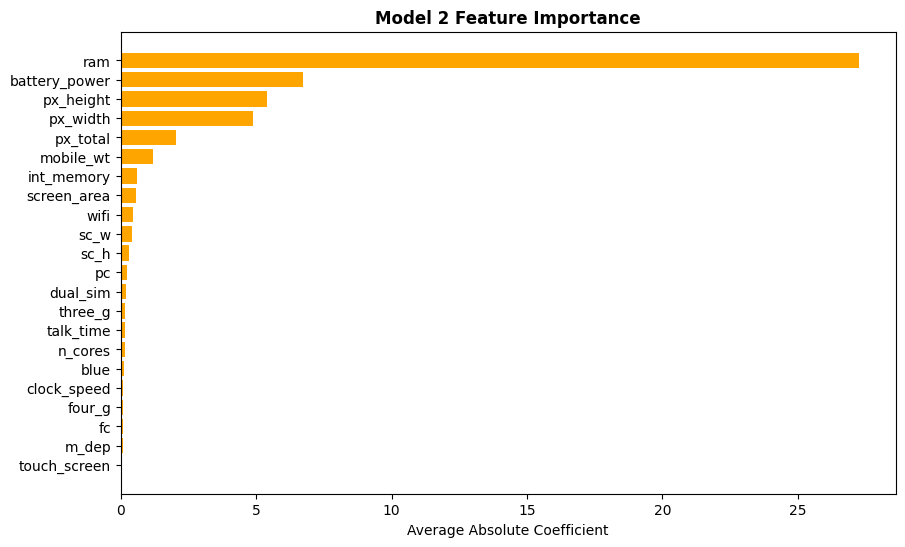

In [ ]:
# Get trained logistic regression model from pipeline
logreg = model2.named_steps['logisticregressioncv']

# Get feature names
feature_names = x_train.columns

# For multiclass, average absolute coefficient across classes
importance_lr2 = np.mean(np.abs(logreg.coef_), axis=0)

# Create DataFrame
importance_df_lr2 = pd.DataFrame({'Feature': feature_names,
                                  'Importance': importance_lr2
                                  }).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df_lr2['Feature'], importance_df_lr2['Importance'], color='orange')
plt.gca().invert_yaxis()
plt.title('Model 2 Feature Importance', weight='bold')
plt.xlabel('Average Absolute Coefficient')
plt.show()

**Interpretation:**

Ram and battery power remain the most important features, demonstrating that although feature transformation improves numerical stability, it does not significantly change the underlying importance ranking, confirming that the dataset's predictive structure is robust.

## ⮞Model 3

In [ ]:
# Neural Network
model3 = make_pipeline(StandardScaler(),
                       MLPClassifier(hidden_layer_sizes=(100,100),
                                     activation='tanh',
                                     solver='lbfgs',
                                     learning_rate_init=0.01,
                                     alpha=0.001,
                                     early_stopping=True,
                                     n_iter_no_change=10,
                                     max_iter=2000,
                                     random_state=10
                                     ))

In [ ]:
model3.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(activation='tanh', alpha=0.001,
                               early_stopping=True,
                               hidden_layer_sizes=(100, 100),
                               learning_rate_init=0.01, max_iter=2000,
                               random_state=10, solver='lbfgs'))])

In [ ]:
y_pred_3 = model3.predict(x_val)
# Model Score
print(f'Model Score={accuracy_score(y_val, y_pred_3)}')
print(f'F1 macro={f1_score(y_val, y_pred_3, average='macro')}')

Model Score=0.975
F1 macro=0.9749843652282677


**Neural Network Hyperparameter Tuning Summary**

| Experiment | Hidden Layers | Activation     | Solver         | Learning Rate | Alpha  | Max Iter | Accuracy   | F1-Macro   | Notes                                                  |
| ---------- | ------------- | -------------- | -------------- | ------------- | ------ | -------- | ---------- | ---------- | ------------------------------------------------------ |
| 1          | (10)          | relu (default) | adam (default) | 0.001        | 0.0001 | 2000     | 0.9125     | 0.9120     | Baseline simple architecture                           |
| 2          | (10, 20)      | relu           | adam           | 0.001        | 0.0001 | 2000     | 0.8750     | 0.8730     | Adding small second layer decreased performance        |
| 3          | (100, 100)    | relu           | adam           | 0.001        | 0.0001 | 2000     | 0.9375     | 0.9371     | Increasing network capacity improved performance       |
| 4          | (50, 30, 10)  | relu           | adam           | 0.001        | 0.0001 | 2000     | 0.9100     | 0.9117     | Deeper but narrower architecture did not help          |
| 5          | (100, 100)    | relu           | adam           | 0.01          | 0.0001 | 2000     | 0.9437     | 0.9432     | Higher learning rate improved convergence              |
| 6          | (100, 100)    | relu           | adam           | 0.01          | 0.001  | 2000     | 0.9500     | 0.9499     | Stronger regularization improved generalization        |
| 7          | (100, 100)    | tanh           | adam           | 0.01          | 0.001  | 2000     | 0.9685     | 0.9687     | Changing activation significantly improved performance |
| 8          | (100, 100)    | tanh           | lbfgs          | auto          | 0.001  | 2000     | **0.9750** | **0.9750** | Best performance; matched logistic regression          |


In [ ]:
print(classification_report(y_val, y_pred_3))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        40
           1       1.00      0.95      0.97        40
           2       1.00      0.95      0.97        40
           3       0.95      1.00      0.98        40

    accuracy                           0.97       160
   macro avg       0.98      0.97      0.97       160
weighted avg       0.98      0.97      0.97       160



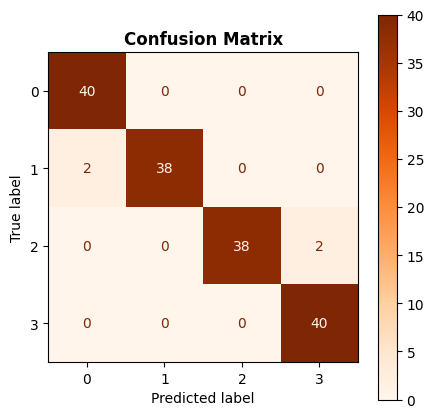

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_val, y_pred_3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Oranges", values_format="d")
ax.set_title("Confusion Matrix", weight="bold")
plt.show()

**Interpretation:**

Same as model1, there are only 4 misclassifications out of 160 samples. Also, most errors occur between adjacent price ranges. This indicates the model correctly captures the ordinal structure of price ranges

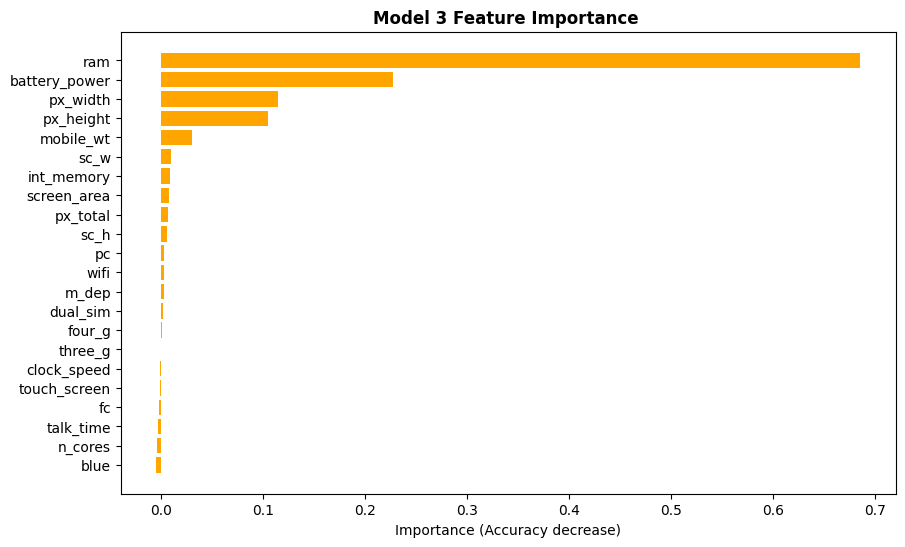

In [ ]:
# Compute permutation importance
result = permutation_importance(model3,
                                x_val,
                                y_val,
                                n_repeats=10,
                                random_state=10,
                                n_jobs=-1)

# Create DataFrame
importance_nn = pd.DataFrame({'Feature': x_val.columns,
                              'Importance': result.importances_mean
                              }).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_nn['Feature'], importance_nn['Importance'], color='orange')
plt.gca().invert_yaxis()
plt.title('Model 3 Feature Importance ', weight='bold')
plt.xlabel('Importance (Accuracy decrease)')
plt.show()

**Interpretation:**

The neural network confirms the same dominant predictors as logistic regression(ram, battery_power, px_width, and height), indicating the relationship between features and price range is largely linear and does not require complex nonlinear modeling.

Feature importance analysis across Logistic Regression and Neural Network models consistently identified RAM as the dominant predictor of mobile price range, followed by battery power and display resolution features. The consistency across linear and nonlinear models indicates that the relationship between hardware specifications and price category is strong, stable, and largely linear. Lower-ranked features such as connectivity options and camera specifications contribute minimally to prediction performance.

## ⮞Retrain the Models on Full Dataset

After completing the hyperparameter tuning using the validation set, the training and validation sets are combined to form a full training dataset. This allows the final models to utilize the maximum amount of available labeled data, improving parameter estimation and generalization.

In [ ]:
# Combine train and validation sets
x_train_full = pd.concat([x_train, x_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

print(x_train_full.shape, y_train_full.shape)

(1600, 22) (1600,)


In [ ]:
# Final Logistic Regression Model
final_logistic = make_pipeline(StandardScaler(),
                               LogisticRegression(class_weight='balanced',
                                                  solver='saga',
                                                  penalty='elasticnet',
                                                  C=2.7825594,
                                                  l1_ratio=1.0,
                                                  max_iter=3000,
                                                  random_state=10)
                               )

In [ ]:
start = time.time()
final_logistic.fit(x_train_full, y_train_full)
lr_time = time.time() - start

In [ ]:
# Final Neural Network Model
final_nn = make_pipeline(StandardScaler(),
                         MLPClassifier(hidden_layer_sizes=(100,100),
                                       activation='tanh',
                                       solver='lbfgs',
                                       learning_rate_init=0.01,
                                       alpha=0.001,
                                       early_stopping=True,
                                       n_iter_no_change=10,
                                       max_iter=2000,
                                       random_state=10)
                         )

In [ ]:
start = time.time()
final_nn.fit(x_train_full, y_train_full)
nn_time = time.time() - start

# 🔶Test the Model

In [ ]:
print(f'Shape of the test set: {test_df.shape}')
test_df.head()

Shape of the test set: (400, 23)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,px_total,screen_area,price_range
501,1773,1,2.5,0,16,1,32,0.6,170,6,...,3566,17,6,13,1,0,1,1788480,102,3
1924,1982,1,1.6,0,2,1,12,0.2,80,5,...,1824,13,3,14,1,1,1,170191,39,1
1710,548,0,1.0,1,0,1,56,0.4,146,4,...,562,17,14,8,1,1,1,1088649,238,0
547,1117,1,0.6,1,0,0,31,0.2,146,2,...,2003,8,7,14,0,1,1,2046766,56,2
496,1554,1,0.5,1,11,0,5,1.0,124,3,...,3635,7,4,18,0,0,0,623705,28,3


## ⮞Split X & Y

In [ ]:
# Separate the dataset into features (X) and the target variable (Y)
x_test = test_df.drop(columns=['price_range'])
y_test = test_df['price_range']

x_test.shape, y_test.shape

((400, 22), (400,))

## ⮞ Evaluation & Model Comparison

In [ ]:
# Predictions
y_pred_lr = final_logistic.predict(x_test)
y_prob_lr = final_logistic.predict_proba(x_test)

y_pred_nn = final_nn.predict(x_test)
y_prob_nn = final_nn.predict_proba(x_test)

In [ ]:
#Evaluation Metrics

# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_nn = accuracy_score(y_test, y_pred_nn)

# F1 score
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
f1_nn = f1_score(y_test, y_pred_nn, average='macro')

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Neural Network"],
    "Accuracy": [acc_lr, acc_nn],
    "F1 Macro": [f1_lr, f1_nn]
})

comparison_df

,Model,Accuracy,F1 Macro
0,Logistic Regression,0.9825,0.982532
1,Neural Network,0.9475,0.947547


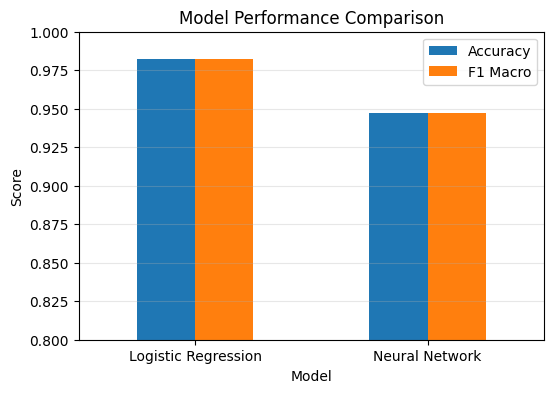

In [ ]:
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(6,4),
    title="Model Performance Comparison"
)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.ylim([0.8,1])
plt.show()

**Key interpretation:**

* Logistic Regression achieved 98.25% accuracy, outperforming the Neural Network by 3.5 percentage points.
* The F1-macro score is identical to accuracy for both models, confirming consistent performance across all four balanced classes.
* The performance gap is significant and indicates that Logistic Regression generalizes better to unseen data.
* This result confirms that the relationship between features and price range is largely linear and well-structured, which Logistic Regression captures effectively.

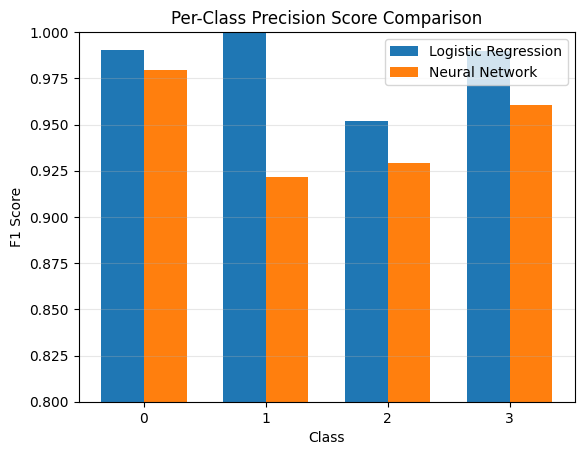

In [ ]:
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_nn = classification_report(y_test, y_pred_nn, output_dict=True)

classes = list(report_lr.keys())[:-3]

precision_lr = [report_lr[c]['precision'] for c in classes]
recall_lr = [report_lr[c]['recall'] for c in classes]
f1_lr = [report_lr[c]['f1-score'] for c in classes]

precision_nn = [report_nn[c]['precision'] for c in classes]
recall_nn = [report_nn[c]['recall'] for c in classes]
f1_nn = [report_nn[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure()
plt.bar(x - width/2, precision_lr, width, label='Logistic Regression')
plt.bar(x + width/2, precision_nn, width, label='Neural Network')

plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Per-Class Precision Score Comparison")
plt.xticks(x, classes)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.ylim([0.8,1])
plt.show()

**Per-Class Precision Interpretation**

Precision measures the proportion of correctly predicted samples among all samples predicted as a given class. In other words, it quantifies how reliable the model’s positive predictions are for each class. A higher precision indicates fewer false positive errors.

The consistently higher precision values across all classes demonstrate that Logistic Regression produces fewer false positives and makes more trustworthy predictions compared to the Neural Network. This indicates that Logistic Regression has learned more effective decision boundaries and generalizes better to unseen test data.

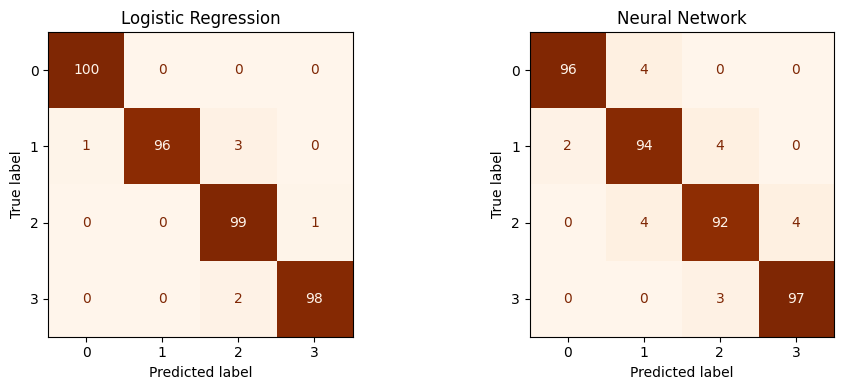

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=ax[0], cmap="Oranges", colorbar=False
)
ax[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nn, ax=ax[1], cmap="Oranges", colorbar=False
)
ax[1].set_title("Neural Network")

plt.tight_layout()
plt.show()

**Key insights:**

**Logistic Regression**
* Class 0:
Perfect classification: 100/100 correct. This class is completely separable from others.

* Class 1:
96 correctly classified. 4 misclassified (1 as Class 0, 3 as Class 2). Minor confusion with neighboring price ranges.

* Class 2:
99 correctly classified. Only 1 misclassified as Class 3

* Class 3:
98 correctly classified.2 misclassified as Class 2

* Overall interpretation:
  * Only 7 misclassifications out of 400 samples.
  * Error rate = 1.75%
  * Misclassifications occur only between adjacent price classes, which is expected because neighboring price ranges share similar technical specifications.
  * There are no severe misclassifications (e.g., Class 0 predicted as Class 3), indicating excellent model discrimination.

**Neural Network**

* Class 0: 4 misclassifications as Class 1
* Class 1: 6 misclassifications (2 as Class 0, 4 as Class 2)
* Class 2: 8 misclassifications (4 as Class 1, 4 as Class 3)
* Class 3: 3 misclassifications as Class 2
* Overall interpretation:
  * Total misclassifications = 21 out of 400 samples
  * Error rate = 5.25%
  * Neural Network shows more frequent confusion between adjacent classes.
  * This indicates weaker decision boundary precision compared to Logistic Regression.

Logistic Regression training time: 2.253 seconds
Neural Network training time: 1.966 seconds


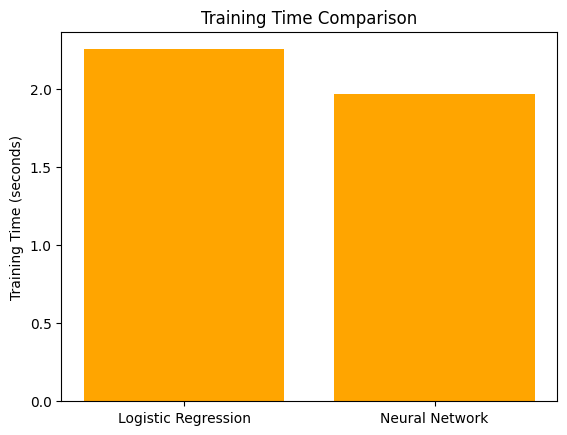

In [ ]:
print(f"Logistic Regression training time: {lr_time:.3f} seconds")
print(f"Neural Network training time: {nn_time:.3f} seconds")

models = ['Logistic Regression', 'Neural Network']
times = [lr_time, nn_time]

plt.figure()
plt.bar(models, times, color='orange')
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.show()

**Interpretation:**

* Neural Network trains slightly faster (≈1 second difference)
* However, the difference is negligible in absolute terms.
* Logistic Regression provides substantially better accuracy with only a minor increase in training time.

Therefore, the small training time advantage of the Neural Network does not justify its lower predictive performance.

**Conclusion:**

Based on the test set evaluation, Logistic Regression achieved superior performance compared to the Neural Network, with an accuracy and F1-macro score of 98.25%, compared to 94.75% for the Neural Network. The confusion matrix analysis shows that Logistic Regression makes fewer misclassifications and demonstrates stronger class separation.

Although the Neural Network had slightly faster training time, the difference was negligible, and Logistic Regression provided significantly better predictive performance and generalization.

These results indicate that the relationship between mobile specifications and price range is largely linear, making Logistic Regression an optimal choice for this problem.